# Project 3: Multi-Agent Reinforcement Learning

### Group 1
### Anton Mlynczyk - 1007283226
### Osman Sultan - 1006803014
### Sunghoo (Kevin) Kim - 1006820013
### Gaeun (Grace) Yim - 1011904824

Please read all instructions carefully before attempting each part of the problem. Each team only needs to have one submission with all the names of team-members and group number at the beginning of the jupyter notebook.

The jupyter notebook should contain your code, discussions, derivations, analysis and relevant figures. Make sure the code, plots and videos shown in your file can be reproduce when I rerun the code in grading. Feel free to add or move Cells.

In this project, you will implement three different multi-agent reinforcement learning algorithms to solve a navi-
gation problem involving two agents and then compare the results.

### 1. The Invader-Defender Game [10 Marks]

The task you will be implementing for this assignment is defined as follow:

- Time is broken up into discrete epochs.
- The world is a square area that is broken up into a 6-by-6 grid of cells.
- There are two players or agents; both of them can move up, down, left, or right. At each time step, both players take their action simultaneously. Each cannot see the others' action at that time step, but the state of the system and previous actions are fully observable to each. If the chosen action takes an agent outside of the grid, then the agent remains in the current position.
- The invader, marked I, starts in the upper-left corner of the world. The defender, marked D, starts in the bottom-left corner of the world.
- The 9 cells centered around the defender's current position (see Figure 1), is the region where the invader has a 90% chance of beign captured. The game ends whenever the invader is captured by the defender, or the invader enters the fixed territory cell marked T, whichever comes first. The discount factor for future rewards is $\gamma = 0.95$.
- The goal of the defender is to capture the invader as far away as possible from the territory T. The goal of the invader is to move as close as possible to the territory T before being captured.


1.1 Explain how you would model this problem as a stochastic game: [10 Marks]

   (a) What is the state space, and what are the action spaces for each agent?

   State Space: Position on the grid of both agents. State: ((p1_loc), (p2_loc)) (e.g) -> ((0, 0), (1, 1))
   
   - Note that there are 6x6x6x6 = 1296 possible states

   Action Space (for each agent): {Left, Right, Up, Down} 

   (b) Describe the transition probability matrix for this stochastic game.

   The transitions are described by a 6^4 x 6^4 matrix that denotes the probability of transitioning from one state to another. It has this dimension because each agent has 36 (6^2) possible positions that it can exist in, and each state models the position of both agents. However, most of the entries within the matrix are zero since each agent can only move to its adjacent grid positions within the board. The action of each agent to its adjacent grid position (or staying in same position due to invalid action) is equiprobable. Also, if the invader is in the defender’s 3x3 zone, there’s a 90% chance of termination (no further transitions).

   (c) Which states, if any, are terminal states?

   - One clear terminal state is when the Invader reaches the Goal (T).

   - The other possible terminal states are when a capture occurs, which depends on the location of the Defender and whether the game terminates with 90% probabiliy. For each location that the Defender is in on the 6x6 grid, if the Invader is within the surrounding 3x3 grid, there is a 90% probability that the game transitions into a terminal state (the Defender captures the Invader).
    
   (d) Derive one suitable reward function that allows the defender to achieve the goal for this task. Derive one suitable reward function that allows the invader to achieve the goal for this task. Are these the only possible suitable reward functions? Why or why not? What is the relationship between the defender's and invader's reward functions? Choosing a good reward function is critical to get good results in RL, so please choose carefully.

   Non-terminal:

   - Invader: (-Manhattan(I, T)) + (+Manhattan(I, D)) 
   - Defender: (+Manhattan(I, T)) + (-Manhattan(I, D))

   Where I = invader position, D = defender position, and T = goal position 

   Terminal:

   - If Captured:
      - Invader: -Manhattan(I, T) 
      - Defender: +Manhattan(I, T)

   - If Invader reach goal:
      - Invader: +20 
      - Defender: -20

   These are not the only possible suitable reward functions. Reward functions can vary as long as they satisfy: 
      - Defender: Maximize invader's distance from T at capture
      - Invader: Minimize distance from T at capture or reaches T

   In this case, the relationship between the defender's and invader's reward functions is zero-sum, meaning that Defender's reward = -Invader's reward.
    
   (e) What kind of stochastic game is this (e.g. what special properties does it possess based on what you have learned about stochastic games)?

   Two-person Zero-sum Stochastic Game with Simultaneous Moves (4 actions per person)

   The reward must add up to 0 for each joint action.

1.2 Now, you are asked to implement the behavior of the invader/defender domain in a Python code. Create a
python class called InvaderDefenderEnv. Here, you should create functions similar to what you have done
in Projects 1 and 2, but for the stochastic game. In particular, you would want to consider functions to:
return a list of possible states in the game; given a state, check if it is terminal; given a transition, return its
probability of occurring and the immediate reward (these should be consistent with your answers to part 1 of
the question); and given a state and actions of the agents, return the next state of the game (to simulate the
task behavior for Q-learning) [10 Marks]


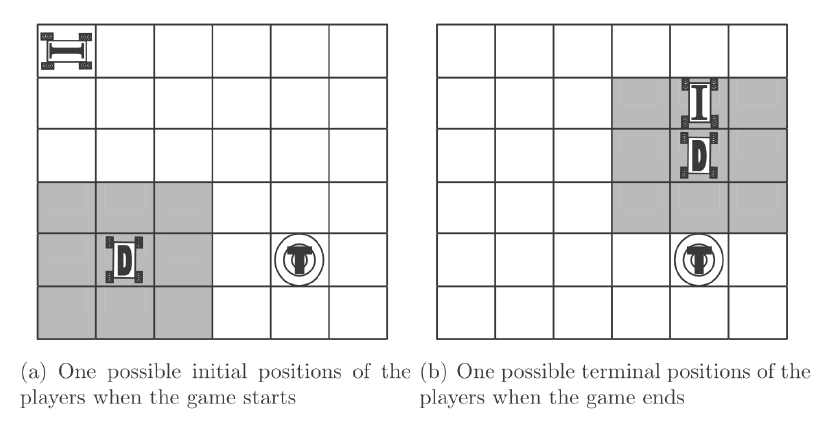

#### 1.2.0 Package Installation

In [ ]:
!pip install numpy

In [2]:
import numpy as np
import random
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.optimize import linprog

#### 1.2.1 Environment Implementation

In [6]:
class InvaderDefenderEnv:
    def __init__(self):
        self.grid_size = 6
        self.territory_pos = (4, 4)   # position of T
        self.invader_pos = (0, 0)     # Starting invader position
        self.defender_pos = (5, 0)    # Starting defender position
        self.actions = ['l', 'r', 'u', 'd']
        self.action_effects = {
            'l': (0, -1),
            'r': (0, 1),
            'u': (-1, 0),
            'd': (1, 0),
        }

    def get_all_states(self):
        # states are defined as: ((invader_loc), (defender_loc))
        states = []
        for i_x in range(self.grid_size):
            for i_y in range(self.grid_size):
                for d_x in range(self.grid_size):
                    for d_y in range(self.grid_size):
                        states.append(((i_x, i_y), (d_x, d_y)))
        return states
    
    def is_terminal(self, state):
        # return True if invader reached T
        invader_pos, _ = state
        return invader_pos == self.territory_pos
    
    def move_agent(self, pos, action):
        # move position of agent based on action
        dx, dy = self.action_effects[action]
        new_x = np.clip(pos[0] + dx, 0, self.grid_size - 1)
        new_y = np.clip(pos[1] + dy, 0, self.grid_size - 1)
        return (new_x, new_y)
    
    def is_in_defender_area(self, invader_pos, defender_pos):
        # check if invader is within defender's 3x3 area
        d_x, d_y = defender_pos
        i_x, i_y = invader_pos
        return (d_x - 1 <= i_x <= d_x + 1) and (d_y - 1 <= i_y <= d_y + 1)
    
    def manhattan_distance(self, pos1, pos2):
        # return manhattan distance between two positions
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])
    
    def get_transition_info(self, state, invader_action, defender_action):
        # return list of all potential transitions along with probailities of each transition happening
        # list contains tuples of (probability, next_state, invader_reward, defender_reward, boolean for terminated)

        invader_pos, defender_pos = state
        transitions = []

        if self.is_terminal(state):
            transitions.append((1.0, state, 0, 0, True))
            return transitions

        # check if invader is in defender's 3x3 area
        in_defender_area = self.is_in_defender_area(invader_pos, defender_pos)

        if in_defender_area:
            # 90% chance of capture (game ends immediately)
            capture_distance = self.manhattan_distance(invader_pos, self.territory_pos)
            transitions.append((
                0.9,
                state,              # no movement
                -capture_distance,  # invader reward
                capture_distance,   # defender reward
                True                # game terminated
            ))

            # 10% chance that both agents move without capture
            new_i_pos = self.move_agent(invader_pos, invader_action)
            new_d_pos = self.move_agent(defender_pos, defender_action)
            new_state = (new_i_pos, new_d_pos)

            # if invader reaches T, terminate
            if new_i_pos == self.territory_pos:
                transitions.append((0.1, new_state, 20, -20, True))
            else:
                # otherwise, move agents
                distance_to_T = self.manhattan_distance(new_i_pos, self.territory_pos)
                distance_to_defender = self.manhattan_distance(new_i_pos, new_d_pos)
                invader_reward = -distance_to_T + distance_to_defender
                defender_reward = distance_to_T - distance_to_defender
                transitions.append((0.1, new_state, invader_reward, defender_reward, False))
        else:
            # no chance for capture, move agents with 100% probability
            new_i_pos = self.move_agent(invader_pos, invader_action)
            new_d_pos = self.move_agent(defender_pos, defender_action)
            new_state = (new_i_pos, new_d_pos)

            # if invader reaches T, terminate
            if new_i_pos == self.territory_pos:
                transitions.append((1.0, new_state, 20, -20, True))
            else:
                # otherwise, move agents
                distance_to_T = self.manhattan_distance(new_i_pos, self.territory_pos)
                distance_to_defender = self.manhattan_distance(new_i_pos, new_d_pos)
                invader_reward = -distance_to_T + distance_to_defender
                defender_reward = distance_to_T - distance_to_defender
                transitions.append((1.0, new_state, invader_reward, defender_reward, False))

        return transitions
    
    def step(self, state, invader_action, defender_action):
        # execute actions given current state. Return next_state, rewards, boolean for terminal state

        # get all potential transitions
        transitions = self.get_transition_info(
            state,
            invader_action,
            defender_action
        )

        # sample a transition based on probabilities
        probs = [t[0] for t in transitions]
        chosen_idx = np.random.choice(len(transitions), p=probs)
        _, next_state, invader_r, defender_r, terminal = transitions[chosen_idx]
        self.invader_pos, self.defender_pos = next_state
        return next_state, (invader_r, defender_r), terminal
    
    def reset(self):
        # reset to initial positions
        self.invader_pos = (0, 0)
        self.defender_pos = (5, 0)
        return (self.invader_pos, self.defender_pos)
    


### 2. Multi-agent Reinforcement Learning [60 Marks]

Now that you have defined the environment needed to perform optimization, you are next asked to implement three
of the standard multi-agent reinforcement learning algorithms you have learned in this course.

2.1. Distributed Q-learning. [20 points]

2.2. Shapley Value Iteration. [20 points]

2.3. MiniMax Q-learning. [20 points]

For MiniMax Q-learning, you should train the algorithm for both agents and sample each agent's own policy to
test them. Investigate whether running the trained policy for both agents would lead to the coordination issue in
the MiniMax Q-learning algorithm.

You can implement each algorithm in a seperate Python function or class. Also, your implementation must have
a train function to run your experiment. Here, you will have to initialize your domain, and the algorithm with your
parameter settings, and run your algorithm.

For each of the three algorithms:

(a) set the value function or Q-values initially to zeros.

(b) for solving an LP, you should use the scipy package (in this case, make sure you are correctly inputting the bounds).

(c) for Q-learning, fix the episode length for training and testing to T = 200.

(d) the number of episodes can be adjusted to obtain convergence as you see necessary; for value iteration, you can stop updates when the maximum difference in value functions between two iterations drops below $10^{-6}$. For Q-learning based methods, you have to define the number episodes required for converge. A criteria for setting up the number of episodes can be maximum difference in value functions. Your criteria should be explained in the project.

(e) in this project, we are giving you full control to experiment with hyper-parameters that you think work well overall (e.g. learning rate, $\epsilon$), but please be consistent in your choice across algorithms.

(f) for all algorithms, testing should be done using the greedy policy on separate rollouts (trajectories) at the end of each training episode.

For each algorithm, you should report the following:

I. a table containing hyper-parameter values you used in your experiments.

II. plots of the training and testing performance over time as a function of the number of training episodes already performed (for value iteration, your training performance can be the error in V between iterations. For algorithms with a Q function training performance over time can be the difference between new and old Q functions. Testing performance over time can be total reward per episode).

III. 2D heat-maps showing: (1) the final value function from the invader's perspective as a function of the invader's starting position, when the defender starting position is fixed at x = 0, y = 5, and (2) the final value function from the defender's perspective as a function of the defender's starting position when the invader's starting position is fixed at x = 0, y = 0.

IV. a pictorial representation (you may include a drawing based on the output of your code) of the agents' motion in the grid during a typical testing episode once the algorithm has converged.

#### 2.1 Distributed Q-Learning

In [ ]:
class DistributedQLearning():
    def __init__(self, env : InvaderDefenderEnv, lr=5e-5, epsilon=0.1, convergence_threshold=1e-4, plot=True):
        self.env = env
        self.alpha = lr
        self.gamma = 0.95 
        self.epsilon = epsilon
        self.convergence_threshold = convergence_threshold
        self.plot = plot
        self.Q_inv = {(state, action): 0 for state in self.env.get_all_states() for action in self.env.actions}
        self.Q_def = {(state, action): 0 for state in self.env.get_all_states() for action in self.env.actions}
        self.Q_inv_old = {(state, action): 0 for state in self.env.get_all_states() for action in self.env.actions}
        self.Q_def_old = {(state, action): 0 for state in self.env.get_all_states() for action in self.env.actions}
        self.policy_inv = {state: {action: 0 for action in self.env.actions} for state in self.env.get_all_states()}
        self.policy_def = {state: {action: 0 for action in self.env.actions} for state in self.env.get_all_states()}


    def reset_policy(self):
        self.policy_inv = {state: {action: 0 for action in self.env.actions} for state in self.env.get_all_states()}
        self.policy_def = {state: {action: 0 for action in self.env.actions} for state in self.env.get_all_states()}


    def epsilon_greedy_policy(self, state):
        prob = random.uniform(0, 1)

        if prob <= self.epsilon:
            return random.choice(self.env.actions), random.choice(self.env.actions)
        else:
            inv_q_max, def_q_max = float('-inf'), float('-inf')
            inv_greedy, def_greedy = 'l', 'l'
            for action in self.env.actions:
                inv_q, def_q = self.Q_inv[(state, action)], self.Q_def[(state, action)]
                if inv_q > inv_q_max:
                    inv_greedy = action
                    inv_q_max = inv_q
                if def_q > def_q_max:
                    def_greedy = action
                    def_q_max = def_q
            return inv_greedy, def_greedy


    def plot_curves(self, num_episodes, inv_q_dff_vals, def_q_diff_vals, inv_reward_vals, def_reward_vals):
        # performance curves
        if num_episodes <= 1000:
            k = 100
        else:
            k = 1000
            
        plt.figure(figsize=(10, 5))
        plt.title("Training Performance: Maximum Difference in Q-values for both Agents")
        plt.plot(range(num_episodes), inv_q_dff_vals, label='Invader')
        plt.plot(range(num_episodes), def_q_diff_vals, label='Defender')
        plt.xticks(range(0, num_episodes, k))
        plt.xlabel("Episode")
        plt.ylabel("Q Difference")
        plt.legend()
        plt.show()

        plt.figure(figsize=(10, 5))
        plt.title("Testing Performance: Total Rewards for both Agents")
        plt.plot(range(num_episodes), inv_reward_vals, label='Invader')
        plt.plot(range(num_episodes), def_reward_vals, label='Defender')
        plt.xticks(range(0, num_episodes, k))
        plt.xlabel("Episode")
        plt.ylabel("Total Reward")
        plt.legend()
        plt.show()

        # heat maps
        # invader perspective
        fixed_defender = (5, 0) # fix defender to starting position of bottom-left of grid
        inv_heat_values = []
        for inv_x in range(6):
            temp = []
            for inv_y in range(6):
                inv_starting = (inv_x, inv_y)
                # compute value as expectation of Q(s,a) over all actions based on policy
                value = 0
                for action in self.env.actions:
                    value += self.policy_inv[(inv_starting, fixed_defender)][action] * self.Q_inv[((inv_starting, fixed_defender), action)]
                temp.append(value)
            inv_heat_values.append(temp)
        inv_heat_values = np.array(inv_heat_values)

        # defender perspective
        fixed_invader = (0, 0)
        def_heat_values = []
        for def_x in range(6):
            temp = []
            for def_y in range(6):
                def_starting = (def_x, def_y)
                value = 0
                for action in self.env.actions:
                    value += self.policy_def[(fixed_invader, def_starting)][action] * self.Q_def[((fixed_invader, def_starting), action)]
                temp.append(value)
            def_heat_values.append(temp)
        def_heat_values = np.array(def_heat_values)
        
        plt.title("Final Value Heat Map from Invader Perspective")
        sns.heatmap(inv_heat_values, annot=True)
        plt.show()

        plt.title("Final Value Heat Map from Defender Perspective")
        sns.heatmap(def_heat_values, annot=True)
        plt.show()


    def execute_policy(self, testing=False):
        curr_state = self.env.reset()
        inv_total_reward, def_total_reward = 0, 0
        terminated = False
        trajectory_counter = 0

        while not terminated:
            # select actions with non-zero probability
            inv_opt_actions, def_opt_actions = [], []
            inv_action_prob, def_action_prob = [], []
            for action in self.env.actions:
                if self.policy_inv[curr_state][action] > 0:
                    inv_opt_actions.append(action)
                    inv_action_prob.append(self.policy_inv[curr_state][action])
                if self.policy_def[curr_state][action] > 0:
                    def_opt_actions.append(action)
                    def_action_prob.append(self.policy_def[curr_state][action])
            
            # execute action
            inv_action = random.choices(inv_opt_actions, inv_action_prob, k=1)[0]
            def_action = random.choices(def_opt_actions, def_action_prob, k=1)[0]
            new_state, (inv_reward, def_reward), terminated = self.env.step(curr_state, inv_action, def_action)
            
            # track reward
            inv_total_reward += inv_reward
            def_total_reward += def_reward

            if testing:
                print(f"Timestamp: {trajectory_counter}")
                print(f"\tCurrent State: {curr_state}")
                print(f"\tInvader Action: {inv_action}; Defender Action: {def_action}")
                print(f"\tNext State: {new_state}")

            trajectory_counter += 1

            # show details of termination if game terminated
            if terminated:
                print("\tGame terminated")
                if new_state == curr_state:
                    print("\tInvader Captured")
                if new_state[0] == self.env.territory_pos:
                    print("\tTerritory Captured")
                print(f"\tTerminating State: {new_state}")
                print(f"\tNumber of Steps: {trajectory_counter}")
                return inv_total_reward, def_total_reward

            # stop if over 200 steps
            if trajectory_counter >= 200:
                print("\tExceeded 200 steps")
                return inv_total_reward, def_total_reward

            curr_state = new_state


    def train(self):
        counter = 0

        # track values for graphing
        inv_q_diff_vals, def_q_diff_vals = [], []
        inv_reward_vals, def_reward_vals = [], []

        while True:
            state = self.env.reset()
            inv_delta, def_delta = 0, 0
            for k in range(200):
                inv_action, def_action = self.epsilon_greedy_policy(state)
                new_state, (inv_reward, def_reward), terminated = self.env.step(state, inv_action, def_action)
                
                # find the max Q value for invader and defender with the new state
                inv_q_max, def_q_max = float('-inf'), float('-inf')
                for action in self.env.actions:
                    inv_q_max, def_q_max = max(self.Q_inv[(new_state, action)], inv_q_max), max(self.Q_def[(new_state, action)], def_q_max)

                # store old Q
                self.Q_inv_old[(state, inv_action)] = self.Q_inv[(state, inv_action)]
                self.Q_def_old[(state, def_action)] = self.Q_def[(state, def_action)]
            
                # update Q independently
                self.Q_inv[(state, inv_action)] += self.alpha * (inv_reward + self.gamma * inv_q_max - self.Q_inv[(state, inv_action)])
                self.Q_def[(state, def_action)] += self.alpha * (def_reward + self.gamma * def_q_max - self.Q_def[(state, def_action)])

                # find difference in update
                inv_delta = max(inv_delta, abs(self.Q_inv_old[(state, inv_action)] - self.Q_inv[(state, inv_action)]))
                def_delta = max(def_delta, abs(self.Q_def_old[(state, def_action)] - self.Q_def[(state, def_action)]))
            
                if terminated:
                    break

                state = new_state

            # implement testing
            # update policy
            self.reset_policy()
            for state in self.env.get_all_states():
                inv_q_max, def_q_max = float('-inf'), float('-inf')
                for action in self.env.actions:
                    inv_q_max, def_q_max = max(self.Q_inv[(state, action)], inv_q_max), max(self.Q_def[(state, action)], def_q_max)
                
                # if action yields max Q, set probability to 1 and then normalize after
                for action in self.env.actions:
                    if abs(self.Q_inv[(state, action)] - inv_q_max) < 1e-8:
                        self.policy_inv[state][action] = 1
                    if abs(self.Q_def[(state, action)] - def_q_max) < 1e-8:
                        self.policy_def[state][action] = 1
                
                num_best_inv = sum(self.policy_inv[state].values())
                num_best_def = sum(self.policy_def[state].values())

                for action, _ in self.policy_inv[state].items():
                    self.policy_inv[state][action] /= num_best_inv
                    self.policy_def[state][action] /= num_best_def

            print(f"Episode {counter + 1}.")
            counter += 1

            # execute policy
            inv_total_reward, def_total_reward = self.execute_policy()

            print(f"\tInvader Reward: {inv_total_reward}; Defender Reward: {def_total_reward}")

            # graphing
            inv_q_diff_vals.append(inv_delta)
            def_q_diff_vals.append(def_delta)
            inv_reward_vals.append(inv_total_reward)
            def_reward_vals.append(def_total_reward)
            
            # only stop if Q values converged
            if inv_delta <= self.convergence_threshold and def_delta <= self.convergence_threshold:
                if self.plot:
                    self.plot_curves(counter, inv_q_diff_vals, def_q_diff_vals, inv_reward_vals, def_reward_vals)
                return self.Q_inv, self.Q_def, self.policy_inv, self.policy_def
        

**2.1) Part I. Hyperaparameter Tuning Experiments**

| Learning Rate | Epsilon | # Episodes until convergence |
| --- | --- | --- |
| 0.7 | 0.1 | over 50k epsidoes and no convergence | 
| 0.7 | 0.01 | over 50k epsidoes and no convergence |
| 0.1 | 0.1 | over 50k epsidoes and no convergence |
| 0.1 | 0.01 | over 50k epsidoes and no convergence |
| 1e-3 | 0.1 | over 50k epsidoes and no convergence |
| 1e-3 | 0.01 | over 50k epsidoes and no convergence |
| 1e-4 | 0.1 | ~21k episodes |
| 1e-4 | 0.01 | ~28k episodes |
| 5e-5 | 0.1 | ~30 episodes |
| 5e-5 | 0.05 | ~45 episode |  
| 5e-5 | 0.01 | ~50 episode |  
| 1e-5 | 0.1 | 1 episode |
| 1e-5 | 0.01 | 1 episode |                         

- 1e-6 was set as the initial threshold value for comparing with the Q-value changes. However, 1e-6 was too small of a threshold as the algorithm didn't converge even with a very small learning rate. So, the threshold was changed to 1e-4 instead - which is still reasonable given the nature of this game and the limitations of this algorithm
- As seen in the table, higher learning rates do not lead to good convergence. A learning rate of 1e-5 terminated the algorithm too quickly and 1e-4 still took over 1000 episodes. Thus, a learning rate in the middle (5e-5) was selected which showed much faster convergence. With this learning rate, after attempting 3 different epsilon values for e-greedy (0.01, 0.05, 0.1); the number of episodes for convergence were all in the similar range, but 0.1 showed the best converged Q values (based on the plots and testing)
- Thus, the best is: Learning Rate = 5e-5; Epislon = 0.1

**2.1) Part II and III**

**NOTE**: For Part III, when making the heat map from the invader's perspective, we have fixed the defender at **(5, 0)** as opposed to the (0, 5) indicated in the instructions. We are assuming that you are telling us to fix the defender in the bottom left corner (its regular starting position) and we have simply used different notation to denote that (being (5,0)).

Episode 1.
	Game terminated
	Territory Captured
	Terminating State: ((4, 4), (5, 2))
	Number of Steps: 69
	Invader Reward: 105; Defender Reward: -105
Episode 2.
	Game terminated
	Territory Captured
	Terminating State: ((4, 4), (0, 1))
	Number of Steps: 44
	Invader Reward: 69; Defender Reward: -69
Episode 3.
	Game terminated
	Invader Captured
	Terminating State: ((2, 3), (2, 2))
	Number of Steps: 30
	Invader Reward: 21; Defender Reward: -21
Episode 4.
	Game terminated
	Invader Captured
	Terminating State: ((3, 1), (4, 0))
	Number of Steps: 13
	Invader Reward: -13; Defender Reward: 13
Episode 5.
	Game terminated
	Invader Captured
	Terminating State: ((4, 0), (5, 1))
	Number of Steps: 15
	Invader Reward: -45; Defender Reward: 45
Episode 6.
	Exceeded 200 steps
	Invader Reward: -600; Defender Reward: 600
Episode 7.
	Game terminated
	Invader Captured
	Terminating State: ((3, 4), (3, 3))
	Number of Steps: 20
	Invader Reward: 12; Defender Reward: -12
Episode 8.
	Game terminated
	Invader Captur

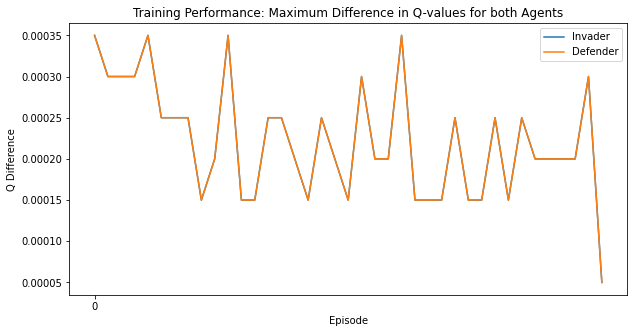

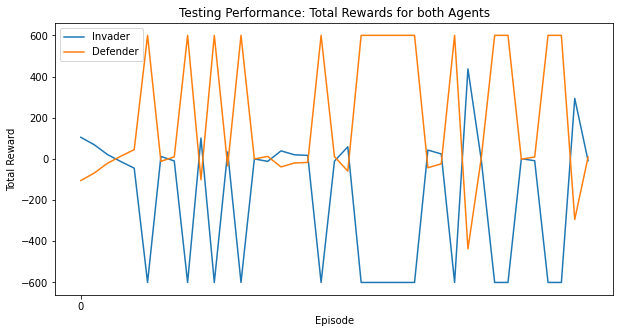

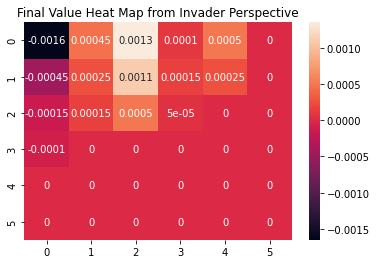

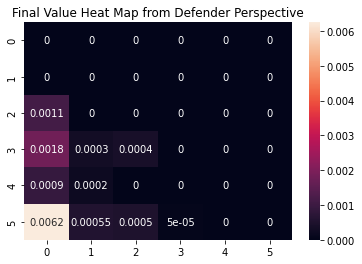

In [23]:
env = InvaderDefenderEnv()
distributed_q_learning = DistributedQLearning(env, lr=5e-5, epsilon=0.1, convergence_threshold=1e-4)
Q_inv, Q_def, policy_inv, policy_def = distributed_q_learning.train()


**2.1) Part IV**

A sample of each agent's movement based on the policy derived from the converged Q-values are shown below. Note that the drawing below is based on one testing instance of running the codeblock below.

In [24]:
_, _ = distributed_q_learning.execute_policy(testing=True)


Timestamp: 0
	Current State: ((0, 0), (5, 0))
	Invader Action: d; Defender Action: l
	Next State: ((1, 0), (5, 0))
Timestamp: 1
	Current State: ((1, 0), (5, 0))
	Invader Action: r; Defender Action: l
	Next State: ((1, 1), (5, 0))
Timestamp: 2
	Current State: ((1, 1), (5, 0))
	Invader Action: r; Defender Action: u
	Next State: ((1, 2), (4, 0))
Timestamp: 3
	Current State: ((1, 2), (4, 0))
	Invader Action: r; Defender Action: u
	Next State: ((1, 3), (3, 0))
Timestamp: 4
	Current State: ((1, 3), (3, 0))
	Invader Action: r; Defender Action: u
	Next State: ((1, 4), (2, 0))
Timestamp: 5
	Current State: ((1, 4), (2, 0))
	Invader Action: u; Defender Action: d
	Next State: ((0, 4), (3, 0))
Timestamp: 6
	Current State: ((0, 4), (3, 0))
	Invader Action: r; Defender Action: u
	Next State: ((0, 5), (2, 0))
Timestamp: 7
	Current State: ((0, 5), (2, 0))
	Invader Action: d; Defender Action: d
	Next State: ((1, 5), (3, 0))
Timestamp: 8
	Current State: ((1, 5), (3, 0))
	Invader Action: u; Defender Actio

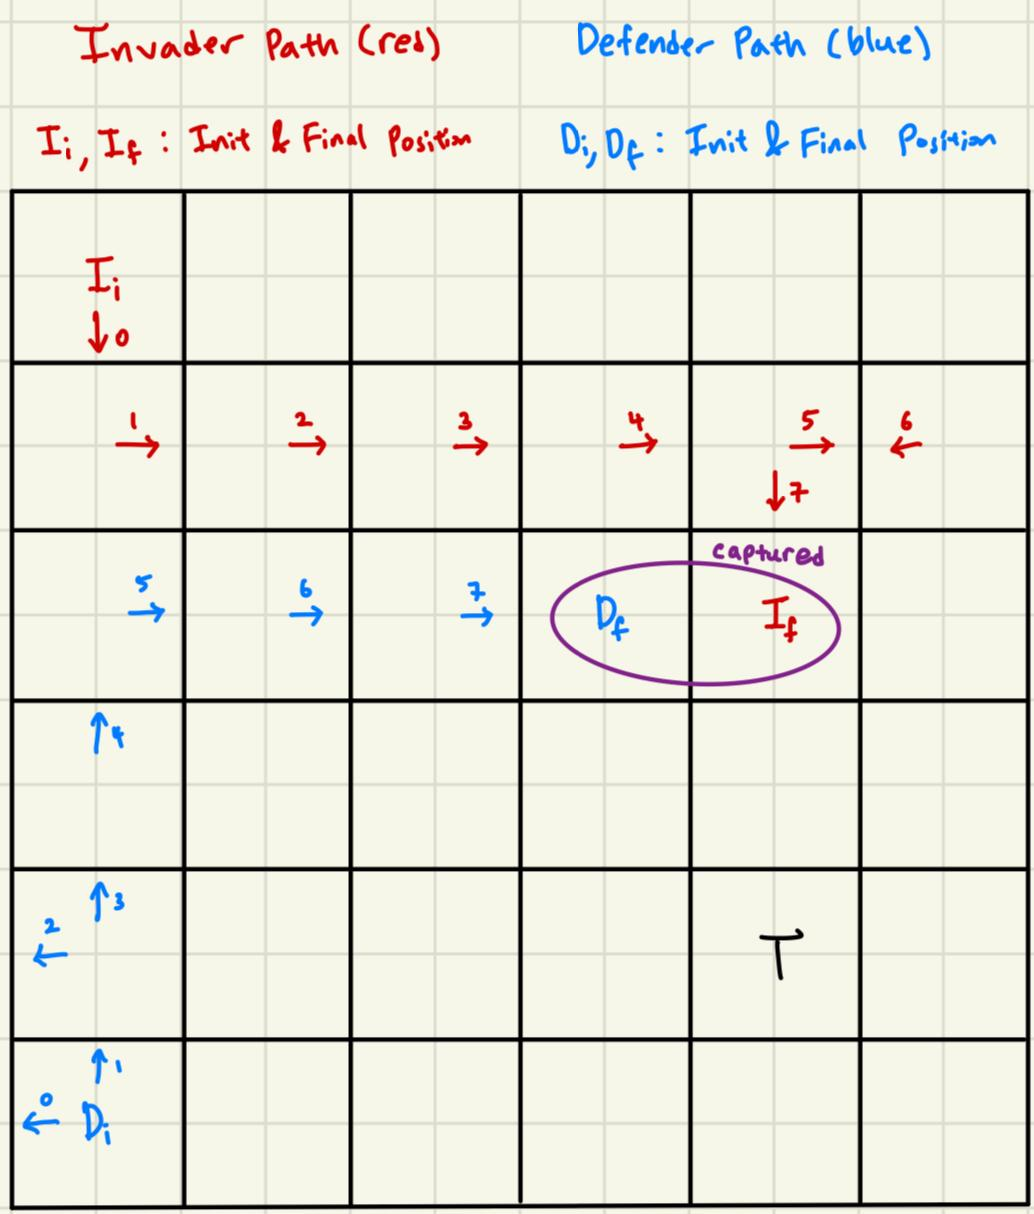

In [25]:
from IPython.display import Image, display
display(Image(filename='fig2.1.4.jpeg', width=400))

#### 2.2 Shapley Value Iteration

In [26]:
class ShapleyValueIteration():
    def __init__(self, env : InvaderDefenderEnv, lr=5e-5, epsilon=0.1, convergence_threshold=1e-6, plot=True):
        self.env = env
        self.alpha = lr
        self.gamma = 0.95 
        self.epsilon = epsilon
        self.convergence_threshold = convergence_threshold
        self.plot=plot
        self.actions = env.actions
        self.U = {state: 0 for state in env.get_all_states()} 
        self.U_old = {state: 0 for state in env.get_all_states()} 
        self.policy_inv = {state: {action: 0 for action in self.env.actions} for state in self.env.get_all_states()}
        self.policy_def = {state: {action: 0 for action in self.env.actions} for state in self.env.get_all_states()}


    def build_G(self, state, role):
        G = {} 
        for a1 in self.actions:
            for a2 in self.actions:

                # calculate g_a
                joint_action = (a1, a2)
                transitions = self.env.get_transition_info(state, a1, a2)
                expected_value = 0
                for prob, next_state, _, _, terminated in transitions: 
                    u_next = 0 if terminated else self.U[next_state]
                    expected_value += prob * u_next

                # expected reward R(s, a) for joint action
                if role == 'invader':
                    R_expected = sum([prob * reward_inv for prob, _, reward_inv, _, _ in transitions]) 
                else:
                    R_expected = sum([prob * reward_def for prob, _, _, reward_def, _ in transitions]) 
                G[joint_action] = R_expected + self.gamma * expected_value 

        return G


    def plot_curves(self, num_episodes, u_diff_vals, inv_reward_vals, def_reward_vals):
        # performance curves
        if num_episodes <= 1000:
            k = 100
        else:
            k = 1000
            
        plt.figure(figsize=(10, 5))
        plt.title("Training Performance: Maximum Difference in V")
        plt.plot(range(num_episodes), u_diff_vals)
        plt.xticks(range(0, num_episodes, k))
        plt.xlabel("Episode")
        plt.ylabel("V Difference")
        plt.show()

        plt.figure(figsize=(10, 5))
        plt.title("Testing Performance: Total Rewards for both Agents")
        plt.plot(range(num_episodes), inv_reward_vals, label='Invader')
        plt.plot(range(num_episodes), def_reward_vals, label='Defender')
        plt.xticks(range(0, num_episodes, k))
        plt.xlabel("Episode")
        plt.ylabel("Total Reward")
        plt.legend()
        plt.show()

        # heat maps
        fixed_defender = (5, 0)
        inv_heat_values = []
        for inv_x in range(6):
            temp = []
            for inv_y in range(6):
                inv_starting = (inv_x, inv_y)
                temp.append(self.U[(inv_starting, fixed_defender)])
            inv_heat_values.append(temp)
        inv_heat_values = np.array(inv_heat_values)

        fixed_invader = (0, 0)
        def_heat_values = []
        for def_x in range(6):
            temp = []
            for def_y in range(6):
                def_starting = (def_x, def_y)
                temp.append(self.U[(fixed_invader, def_starting)])
            def_heat_values.append(temp)
        def_heat_values = np.array(def_heat_values)

        plt.title("Final Value Heat Map from Invader Perspective")
        sns.heatmap(inv_heat_values, annot=True)
        plt.show()

        plt.title("Final Value Heat Map from Defender Perspective")
        sns.heatmap(def_heat_values, annot=True)
        plt.show()


    def execute_policy(self, testing=False):
        curr_state = self.env.reset()
        inv_total_reward, def_total_reward = 0, 0
        terminated = False
        trajectory_counter = 0
        while not terminated:
            inv_opt_actions, def_opt_actions = [], []
            inv_action_prob, def_action_prob = [], []
            for action in self.env.actions:
                if self.policy_inv[curr_state][action] > 0:
                    inv_opt_actions.append(action)
                    inv_action_prob.append(self.policy_inv[curr_state][action])
                if self.policy_def[curr_state][action] > 0:
                    def_opt_actions.append(action)
                    def_action_prob.append(self.policy_def[curr_state][action])
            
            inv_action = random.choices(inv_opt_actions, inv_action_prob, k=1)[0]
            def_action = random.choices(def_opt_actions, def_action_prob, k=1)[0]
            
            new_state, (inv_reward, def_reward), terminated = self.env.step(curr_state, inv_action, def_action)
            
            inv_total_reward += inv_reward
            def_total_reward += def_reward

            if testing:
                print(f"Timestamp: {trajectory_counter}")
                print(f"\tCurrent State: {curr_state}")
                print(f"\tInvader Action: {inv_action}; Defender Action: {def_action}")
                print(f"\tNext State: {new_state}")

            trajectory_counter += 1
    
            if terminated:
                print("\tGame terminated")
                if new_state == curr_state:
                    print("\tInvader Captured")
                if new_state[0] == self.env.territory_pos:
                    print("\tTerritory Captured")
                print(f"\tTerminating State: {new_state}")
                print(f"\tNumber of Steps: {trajectory_counter}")
                return inv_total_reward, def_total_reward

            if trajectory_counter >= 200:
                print("\tExceeded 200 steps")
                return inv_total_reward, def_total_reward

            curr_state = new_state


    def solve_shapley_lp(self, inv_G_s, def_G_s):

        num_actions = len(self.actions)

        # LP for invader (primal)
        c_inv = [0] * num_actions + [-1]  # min -v
        A_inv = []
        b_inv = [0] * num_actions
        for j in range(4):
            row = []
            for i in range(4):
                row.append(-inv_G_s[(self.actions[i], self.actions[j])])
            row.append(1)
            A_inv.append(row)
        A_eq_inv = [[1] * num_actions + [0]]
        b_eq_inv = [1]
        bounds_inv = [(0, 1)] * num_actions + [(None, None)]

        res_inv = linprog(c_inv, A_ub=A_inv, b_ub=b_inv, A_eq=A_eq_inv, b_eq=b_eq_inv, bounds=bounds_inv)

        # LP for defender (dual)
        c_def = [0] * num_actions + [1]  # min w
        A_def = []
        b_def = [0] * num_actions
        for i in range(4):
            row = []
            for j in range(4):
                row.append(def_G_s[(self.actions[i], self.actions[j])])
            row.append(-1)
            A_def.append(row)
        A_eq_def = [[1] * num_actions + [0]]
        b_eq_def = [1]
        bounds_def = [(0, 1)] * num_actions + [(None, None)]

        res_def = linprog(c_def, A_ub=A_def, b_ub=b_def, A_eq=A_eq_def, b_eq=b_eq_def, bounds=bounds_def)

        if res_inv.success and res_def.success:
            pi_inv = res_inv.x[:4]
            pi_def = res_def.x[:4]
            v = res_inv.x[-1]
            return v, pi_inv, pi_def
        else:
            raise RuntimeError("LP failed for invader or defender")


    def train(self):
        counter = 0
        u_diff_vals = []
        inv_reward_vals, def_reward_vals = [], []
        while True:
            delta = 0
            for state in self.env.get_all_states():
                if self.env.is_terminal(state):
                    self.U[state] = 0
                    continue
            
                # construct G
                inv_G_s = self.build_G(state, "invader")
                def_G_s = self.build_G(state, "defender")
                value, pi_inv, pi_def = self.solve_shapley_lp(inv_G_s, def_G_s) # solve LP to find policy

                # store old U, update U
                self.U_old[state] = self.U[state]
                self.U[state] = value

                # find difference in update
                delta = max(delta, abs(self.U_old[state] - self.U[state]))

                # update policy
                for i, a in enumerate(self.actions):
                    self.policy_inv[state][a] = pi_inv[i]
                    self.policy_def[state][a] = pi_def[i]

            print(f"Episode {counter + 1}.")
            counter += 1

            # implement testing
            # execute policy
            inv_total_reward, def_total_reward = self.execute_policy()
            print(f"\tInvader Reward: {inv_total_reward}; Defender Reward: {def_total_reward}")
                    
            # graphing
            u_diff_vals.append(delta)
            inv_reward_vals.append(inv_total_reward)
            def_reward_vals.append(def_total_reward)

            # only stop if U values converged
            if delta <= self.convergence_threshold:
                for state in self.env.get_all_states():
                    inv_G_s = self.build_G(state, "invader")
                    def_G_s = self.build_G(state, "defender")
                    value, pi_inv, pi_def = self.solve_shapley_lp(inv_G_s, def_G_s) 
                    # update policy
                    for i, a in enumerate(self.actions):
                        self.policy_inv[state][a] = pi_inv[i]
                        self.policy_def[state][a] = pi_def[i]
                
                if self.plot:
                    self.plot_curves(counter, u_diff_vals, inv_reward_vals, def_reward_vals)
                return self.U, self.policy_inv, self.policy_def
            

**2.2) Part I. Hyperparameter Tuning Experiments**

Hyperparameter combinations tested are consistent with Distributed Q-Learning.

| Learning Rate | Epsilon | # Episodes until convergence |
| --- | --- | --- |
| 0.7 | 0.1 | 9 episodes | 
| 0.7 | 0.01 | 9 episodes  |
| 0.1 | 0.1 | 9 episodes |
| 0.1 | 0.01 | 9 episodes |
| 1e-3 | 0.1 | 9 episodes |
| 1e-3 | 0.01 | 9 episodes |
| 1e-4 | 0.1 | 9 episodes |
| 1e-4 | 0.01 | 9 episodes |
| 5e-5 | 0.1 | 9 episodes |
| 5e-5 | 0.05 | 9 episodes |
| 5e-5 | 0.01 | 9 episodes |
| 1e-5 | 0.1 | 9 episodes |
| 1e-5 | 0.01 | 9 episodes |

This algorithm was extremely stable to the point where hyperparameters did not seem to have a great effect as they all terminate in 9 episodes. Thus, the hyperparameters are chosen as the same as Distributed Q-Learning, which is:

- learning rate = 5e-5 
- $\epsilon$ = 0.1


**2.2) Part II and III**

**NOTE**: For Part III, when making the heat map from the invader's perspective, we have fixed the defender at **(5, 0)** as opposed to the (0, 5) indicated in the instructions. We are assuming that you are telling us to fix the defender in the bottom left corner (its regular starting position) and we have simply used different notation to denote that (being (5,0)).

**NOTE 2**: For the plots and heatmaps below, we have opted to use Learning rate = 5e-5 and Epsilon = 0.1 to remain consistent with the plots and heatmaps from section 2.1, as indicated in the project instructions.

Episode 1.
	Exceeded 200 steps
	Invader Reward: 791; Defender Reward: -791
Episode 2.
	Exceeded 200 steps
	Invader Reward: 875; Defender Reward: -875
Episode 3.
	Game terminated
	Invader Captured
	Terminating State: ((2, 4), (2, 3))
	Number of Steps: 7
	Invader Reward: -5; Defender Reward: 5
Episode 4.
	Game terminated
	Invader Captured
	Terminating State: ((2, 4), (2, 3))
	Number of Steps: 7
	Invader Reward: -5; Defender Reward: 5
Episode 5.
	Game terminated
	Invader Captured
	Terminating State: ((2, 4), (2, 3))
	Number of Steps: 7
	Invader Reward: -5; Defender Reward: 5
Episode 6.
	Game terminated
	Invader Captured
	Terminating State: ((3, 4), (2, 4))
	Number of Steps: 8
	Invader Reward: -4; Defender Reward: 4
Episode 7.
	Game terminated
	Invader Captured
	Terminating State: ((2, 4), (3, 4))
	Number of Steps: 7
	Invader Reward: -5; Defender Reward: 5
Episode 8.
	Game terminated
	Invader Captured
	Terminating State: ((2, 4), (3, 4))
	Number of Steps: 7
	Invader Reward: -5; Defender Re

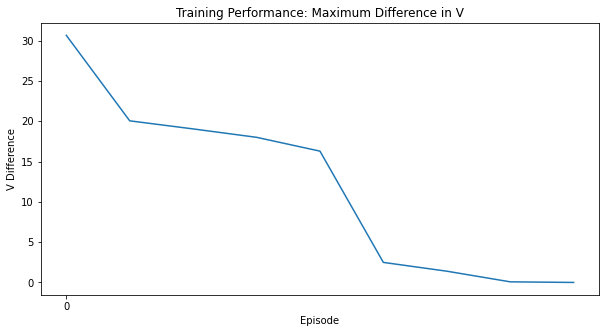

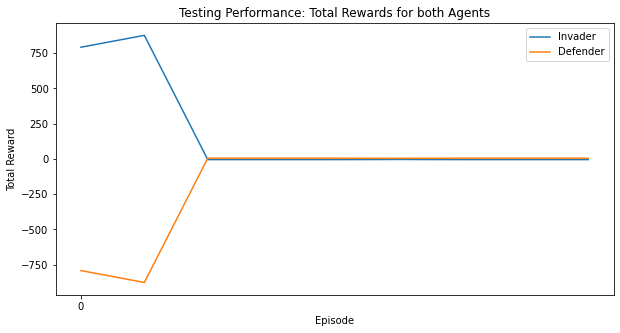

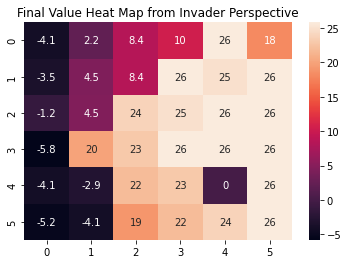

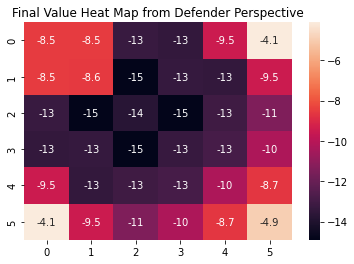

In [27]:
env = InvaderDefenderEnv()
shapley_value_iteration = ShapleyValueIteration(env, lr=5e-5, epsilon=0.1)
U, policy_inv, policy_def = shapley_value_iteration.train()

**2.2) Part IV**

A sample of each agent's movement based on the policy derived from the converged values are shown below. Note that the drawing below is based on one testing instance of running the codeblock below.

In [28]:
_, _ = shapley_value_iteration.execute_policy(testing=True)

Timestamp: 0
	Current State: ((0, 0), (5, 0))
	Invader Action: r; Defender Action: r
	Next State: ((0, 1), (5, 1))
Timestamp: 1
	Current State: ((0, 1), (5, 1))
	Invader Action: r; Defender Action: u
	Next State: ((0, 2), (4, 1))
Timestamp: 2
	Current State: ((0, 2), (4, 1))
	Invader Action: r; Defender Action: u
	Next State: ((0, 3), (3, 1))
Timestamp: 3
	Current State: ((0, 3), (3, 1))
	Invader Action: r; Defender Action: r
	Next State: ((0, 4), (3, 2))
Timestamp: 4
	Current State: ((0, 4), (3, 2))
	Invader Action: d; Defender Action: r
	Next State: ((1, 4), (3, 3))
Timestamp: 5
	Current State: ((1, 4), (3, 3))
	Invader Action: d; Defender Action: r
	Next State: ((2, 4), (3, 4))
Timestamp: 6
	Current State: ((2, 4), (3, 4))
	Invader Action: d; Defender Action: u
	Next State: ((2, 4), (3, 4))
	Game terminated
	Invader Captured
	Terminating State: ((2, 4), (3, 4))
	Number of Steps: 7


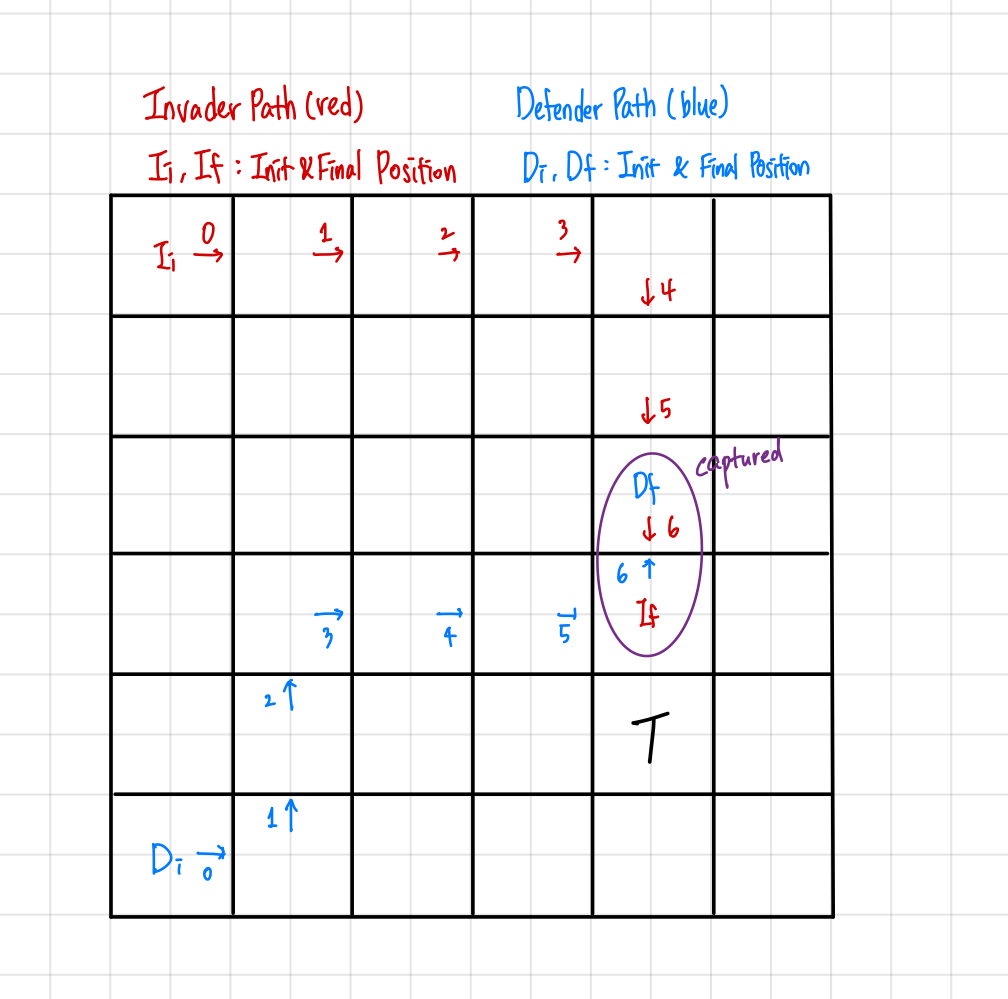

In [14]:
from IPython.display import Image, display
display(Image(filename='fig2.2.4.jpeg', width=400))

#### 2.3 Minimax Q-learning

In [29]:
class MinimaxQLearning():
    def __init__(self, env : InvaderDefenderEnv, lr=5e-5, epsilon=0.1, convergence_threshold=1e-4, plot=True):
        self.env = env
        self.alpha = lr
        self.gamma = 0.95 
        self.epsilon = epsilon
        self.convergence_threshold = convergence_threshold
        self.plot = plot
        self.actions = env.actions
        self.Q_inv = {(state, inv_action, def_action): 0 for state in self.env.get_all_states() for inv_action in self.env.actions for def_action in self.env.actions}
        self.Q_def = {(state, inv_action, def_action): 0 for state in self.env.get_all_states() for inv_action in self.env.actions for def_action in self.env.actions}
        self.Q_inv_old = {(state, inv_action, def_action): 0 for state in self.env.get_all_states() for inv_action in self.env.actions for def_action in self.env.actions}
        self.Q_def_old = {(state, inv_action, def_action): 0 for state in self.env.get_all_states() for inv_action in self.env.actions for def_action in self.env.actions}
        self.policy_inv = {state: {action: 0 for action in self.env.actions} for state in self.env.get_all_states()}
        self.policy_def = {state: {action: 0 for action in self.env.actions} for state in self.env.get_all_states()}


    def build_G(self, state, role):
        G = {} 
        for a1 in self.actions:
            for a2 in self.actions:
                if role == "invader":
                    G[(a1, a2)] = self.Q_inv[(state, a1, a2)]
                else:
                    G[(a1, a2)] = self.Q_def[(state, a1, a2)]

        return G


    def get_actions(self, state):
        prob = random.uniform(0, 1)

        # randomly select actions with epsilon probability, and otherwise select action with highest probability based on policy
        if prob <= self.epsilon:
            return random.choice(self.env.actions), random.choice(self.env.actions)
        else:
            inv_max_prob = max(self.policy_inv[state].values())
            def_max_prob = max(self.policy_def[state].values())
            inv_action, def_action = 'l', 'l'
            for action in self.env.actions:
                if abs(self.policy_inv[state][action] - inv_max_prob) < 1e-8:
                    inv_action = action
                if abs(self.policy_def[state][action] - def_max_prob) < 1e-8:
                    def_action = action
            
            return inv_action, def_action


    def plot_curves(self, num_episodes, inv_q_dff_vals, def_q_diff_vals, inv_reward_vals, def_reward_vals):
        # performance curves
        if num_episodes <= 1000:
            k = 100
        else:
            k = 1000
            
        plt.figure(figsize=(10, 5))
        plt.title("Training Performance: Maximum Difference in Q-values for both Agents")
        plt.plot(range(num_episodes), inv_q_dff_vals, label='Invader')
        plt.plot(range(num_episodes), def_q_diff_vals, label='Defender')
        plt.xticks(range(0, num_episodes, k))
        plt.xlabel("Episode")
        plt.ylabel("Q Difference")
        plt.legend()
        plt.show()

        plt.figure(figsize=(10, 5))
        plt.title("Testing Performance: Total Rewards for both Agents")
        plt.plot(range(num_episodes), inv_reward_vals, label='Invader')
        plt.plot(range(num_episodes), def_reward_vals, label='Defender')
        plt.xticks(range(0, num_episodes, k))
        plt.xlabel("Episode")
        plt.ylabel("Total Reward")
        plt.legend()
        plt.show()

        # heat maps
        fixed_defender = (5, 0)
        inv_heat_values = []
        for inv_x in range(6):
            temp = []
            for inv_y in range(6):
                inv_starting = (inv_x, inv_y)
                # compute value as expectation of Q(s, a1, a2) over all joint actions based on policy of both agents
                value = 0
                for a1 in self.env.actions:
                    for a2 in self.env.actions:
                        value += self.policy_inv[(inv_starting, fixed_defender)][a1] * self.policy_def[(inv_starting, fixed_defender)][a2] * self.Q_inv[((inv_starting, fixed_defender), a1, a2)]
                temp.append(value)
            inv_heat_values.append(temp)
        inv_heat_values = np.array(inv_heat_values)

        fixed_invader = (0, 0)
        def_heat_values = []
        for def_x in range(6):
            temp = []
            for def_y in range(6):
                def_starting = (def_x, def_y)
                value = 0
                for a1 in self.env.actions:
                    for a2 in self.env.actions:
                        value += self.policy_inv[(fixed_invader, def_starting)][a1] * self.policy_def[(fixed_invader, def_starting)][a2] * self.Q_def[((fixed_invader, def_starting), a1, a2)]
                temp.append(value)
            def_heat_values.append(temp)
        def_heat_values = np.array(def_heat_values)
        
        plt.title("Final Value Heat Map from Invader Perspective")
        sns.heatmap(inv_heat_values, annot=True)
        plt.show()

        plt.title("Final Value Heat Map from Defender Perspective")
        sns.heatmap(def_heat_values, annot=True)
        plt.show()


    def execute_policy(self, testing=False):
        curr_state = self.env.reset()
        inv_total_reward, def_total_reward = 0, 0
        terminated = False
        trajectory_counter = 0
        while not terminated:
            inv_opt_actions, def_opt_actions = [], []
            inv_action_prob, def_action_prob = [], []
            for action in self.env.actions:
                if self.policy_inv[curr_state][action] > 0:
                    inv_opt_actions.append(action)
                    inv_action_prob.append(self.policy_inv[curr_state][action])
                if self.policy_def[curr_state][action] > 0:
                    def_opt_actions.append(action)
                    def_action_prob.append(self.policy_def[curr_state][action])
            
            inv_action = random.choices(inv_opt_actions, inv_action_prob, k=1)[0]
            def_action = random.choices(def_opt_actions, def_action_prob, k=1)[0]

            new_state, (inv_reward, def_reward), terminated = self.env.step(curr_state, inv_action, def_action)
            
            inv_total_reward += inv_reward
            def_total_reward += def_reward

            if testing:
                print(f"Timestamp: {trajectory_counter}")
                print(f"\tCurrent State: {curr_state}")
                print(f"\tInvader Action: {inv_action}; Defender Action: {def_action}")
                print(f"\tNext State: {new_state}")

            trajectory_counter += 1
    
            if terminated:
                print("\tGame terminated")
                if new_state == curr_state:
                    print("\tInvader Captured")
                if new_state[0] == self.env.territory_pos:
                    print("\tTerritory Captured")
                print(f"\tTerminating State: {new_state}")
                print(f"\tNumber of Steps: {trajectory_counter}")
                return inv_total_reward, def_total_reward

            if trajectory_counter >= 200:
                print("\tExceeded 200 steps")
                return inv_total_reward, def_total_reward

            curr_state = new_state


    def solve_minimax_lp(self, inv_G_s, def_G_s):

        num_actions = len(self.actions)

        # LP for invader (primal)
        c_inv = [0] * num_actions + [-1]  
        A_inv = []
        b_inv = [0] * num_actions
        for j in range(4):
            row = []
            for i in range(4):
                row.append(-inv_G_s[(self.actions[i], self.actions[j])])
            row.append(1)
            A_inv.append(row)
        A_eq_inv = [[1] * num_actions + [0]]
        b_eq_inv = [1]
        bounds_inv = [(0, 1)] * num_actions + [(None, None)]

        res_inv = linprog(c_inv, A_ub=A_inv, b_ub=b_inv, A_eq=A_eq_inv, b_eq=b_eq_inv, bounds=bounds_inv)

        # LP for defender (dual)
        c_def = [0] * num_actions + [1] 
        A_def = []
        b_def = [0] * num_actions
        for i in range(4):
            row = []
            for j in range(4):
                row.append(def_G_s[(self.actions[i], self.actions[j])])
            row.append(-1)
            A_def.append(row)
        A_eq_def = [[1] * num_actions + [0]]
        b_eq_def = [1]
        bounds_def = [(0, 1)] * num_actions + [(None, None)]

        res_def = linprog(c_def, A_ub=A_def, b_ub=b_def, A_eq=A_eq_def, b_eq=b_eq_def, bounds=bounds_def)

        if res_inv.success and res_def.success:
            pi_inv = res_inv.x[:4]
            pi_def = res_def.x[:4]
            v = res_inv.x[-1]
            return v, pi_inv, pi_def
        else:
            raise RuntimeError("LP failed for invader or defender")


    def train(self):
        counter = 0
        inv_q_diff_vals, def_q_diff_vals = [], []
        inv_reward_vals, def_reward_vals = [], []

        while True: 
            state = self.env.reset()
            inv_G_s = self.build_G(state, "invader")
            def_G_s = self.build_G(state, "defender")
            _, pi_inv, pi_def = self.solve_minimax_lp(inv_G_s, def_G_s)

            # update policy
            for i, a in enumerate(self.actions):
                self.policy_inv[state][a] = pi_inv[i]
                self.policy_def[state][a] = pi_def[i]

            inv_delta, def_delta = 0, 0

            for k in range(200):
                # get action from policy (with epsilon randomness), get new state, and rewards
                inv_action, def_action = self.get_actions(state)
                new_state, _, terminated = self.env.step(state, inv_action, def_action)
                transitions = self.env.get_transition_info(state, inv_action, def_action)

                # build G with new state
                inv_G_s_new = self.build_G(new_state, "invader")
                def_G_s_new = self.build_G(new_state, "defender")

                # get policy for new state 
                value, pi_inv_new, pi_def_new = self.solve_minimax_lp(inv_G_s_new, def_G_s_new)
                for i, a in enumerate(self.actions):
                    self.policy_inv[state][a] = pi_inv_new[i]
                    self.policy_def[state][a] = pi_def_new[i]

                # update Q
                self.Q_inv_old[(state, inv_action, def_action)] = self.Q_inv[(state, inv_action, def_action)]
                self.Q_def_old[(state, inv_action, def_action)] = self.Q_def[(state, inv_action, def_action)]

                inv_R_expected = sum([prob * reward_inv for prob, _, reward_inv, _, _ in transitions])
                def_R_expected = sum([prob * reward_def for prob, _, _, reward_def, _ in transitions])
                self.Q_inv[(state, inv_action, def_action)] += self.alpha * (inv_R_expected + self.gamma * value - self.Q_inv[(state, inv_action, def_action)])
                self.Q_def[(state, inv_action, def_action)] += self.alpha * (def_R_expected + self.gamma * (-value) - self.Q_def[(state, inv_action, def_action)])   # minimax value of defender is -(invader's value)

                # find difference in update
                inv_delta = max(inv_delta, abs(self.Q_inv[(state, inv_action, def_action)] - self.Q_inv_old[(state, inv_action, def_action)]))
                def_delta = max(def_delta, abs(self.Q_def[(state, inv_action, def_action)] - self.Q_def_old[(state, inv_action, def_action)]))

                if terminated:
                    break

                state = new_state

            print(f"Episode {counter + 1}.")
            counter += 1

            # implement testing
            # update policy
            for state in self.env.get_all_states():
                inv_G_s = self.build_G(state, "invader")
                def_G_s = self.build_G(state, "defender")
                value, pi_inv, pi_def = self.solve_minimax_lp(inv_G_s, def_G_s)
                for i, a in enumerate(self.actions):
                    self.policy_inv[state][a] = pi_inv[i]
                    self.policy_def[state][a] = pi_def[i]

            # execute policy
            inv_total_reward, def_total_reward = self.execute_policy()
            print(f"\tInvader Reward: {inv_total_reward}; Defender Reward: {def_total_reward}")
                    
            # graphing
            inv_q_diff_vals.append(inv_delta)
            def_q_diff_vals.append(def_delta)
            inv_reward_vals.append(inv_total_reward)
            def_reward_vals.append(def_total_reward)

            # only stop if Q values converged
            if inv_delta <= self.convergence_threshold and def_delta <= self.convergence_threshold:
                if self.plot:
                    self.plot_curves(counter, inv_q_diff_vals, def_q_diff_vals, inv_reward_vals, def_reward_vals)
                return self.Q_inv, self.Q_def, self.policy_inv, self.policy_def
            

**2.3) Part I. Hyperparameter Tuning Experiments**

| Learning Rate | Epsilon | # Episodes until convergence |
| --- | --- | --- |
| 0.7 | 0.1 | >50 episodes | 
| 0.7 | 0.01 | ~10-20 episodes, sometimes >50 episodes  |
| 0.1 | 0.1 | >50 episodes |
| 0.1 | 0.01 | >50 episodes |
| 1e-3 | 0.1 | >50 episodes |
| 1e-3 | 0.01 | >50 episodes |
| 1e-4 | 0.1 | >50 episodes |
| 1e-4 | 0.01 | >50 episodes |
| 5e-5 | 0.1 | ~10-20 episodes, sometimes >50 episodes |
| 5e-5 | 0.05 | ~10-20 episodes, sometimes >50 episodes |
| 5e-5 | 0.01 | ~10-20 episodes, sometimes >50 episodes |
| 1e-5 | 0.1 | ~10-20 episodes, sometimes >50 episodes |
| 1e-5 | 0.01 | ~10-20 episodes, sometimes >50 episodes |

Hyperparameter tuning did not prove to be reliable, Minimax Q-learning seems to be highly unstable. In general, lower learning rates tended to do better but cannot make a conclusion on best hyperparameters. For analysis below, the same hyperparameters were selected as Distributed Q-learning which is:

- learning rate = 5e-5 
- $\epsilon$ = 0.1

**2.3) Part II and III**

**NOTE**: For Part III, when making the heat map from the invader's perspective, we have fixed the defender at **(5, 0)** as opposed to the (0, 5) indicated in the instructions. We are assuming that you are telling us to fix the defender in the bottom left corner (its regular starting position) and we have simply used different notation to denote that (being (5,0)).

**NOTE 2**: For the plots and heatmaps below, we have opted to use Learning rate = 5e-5 and Epsilon = 0.1 to remain consistent with the plots and heatmaps from section 2.1, as indicated in the project instructions.

Episode 1.
	Exceeded 200 steps
	Invader Reward: -800; Defender Reward: 800
Episode 2.
	Exceeded 200 steps
	Invader Reward: -600; Defender Reward: 600
Episode 3.
	Game terminated
	Invader Captured
	Terminating State: ((4, 0), (5, 0))
	Number of Steps: 11
	Invader Reward: -36; Defender Reward: 36
Episode 4.
	Exceeded 200 steps
	Invader Reward: -1094; Defender Reward: 1094
Episode 5.
	Exceeded 200 steps
	Invader Reward: -886; Defender Reward: 886
Episode 6.
	Game terminated
	Invader Captured
	Terminating State: ((2, 0), (3, 0))
	Number of Steps: 5
	Invader Reward: -22; Defender Reward: 22
Episode 7.
	Exceeded 200 steps
	Invader Reward: -103; Defender Reward: 103
Episode 8.
	Exceeded 200 steps
	Invader Reward: -137; Defender Reward: 137
Episode 9.
	Exceeded 200 steps
	Invader Reward: -122; Defender Reward: 122
Episode 10.
	Game terminated
	Invader Captured
	Terminating State: ((2, 0), (3, 0))
	Number of Steps: 3
	Invader Reward: -15; Defender Reward: 15
Episode 11.
	Exceeded 200 steps
	Inv

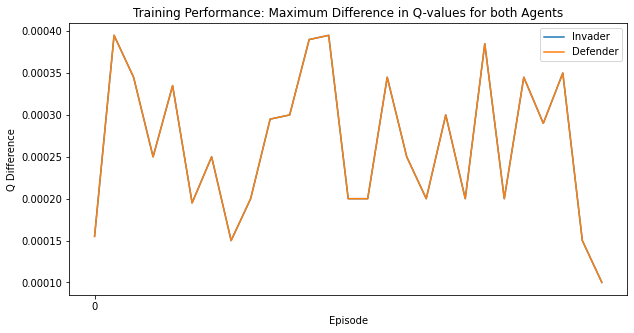

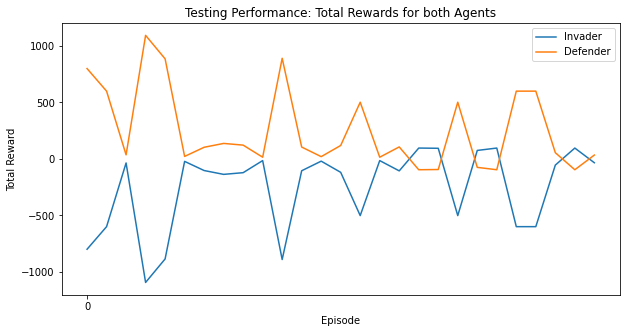

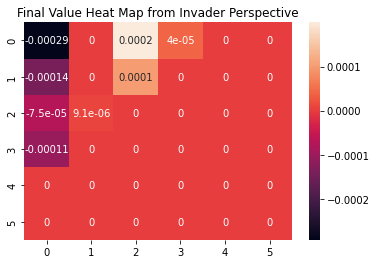

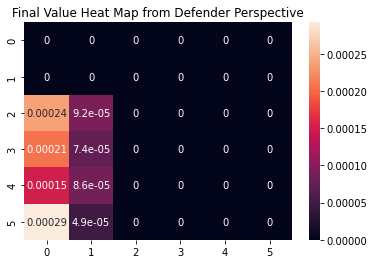

In [30]:
env = InvaderDefenderEnv()
minimax_q_learning = MinimaxQLearning(env, lr=5e-5, epsilon=0.1, convergence_threshold=1e-4)
Q_inv, Q_def, policy_inv, policy_def = minimax_q_learning.train()

**2.3) Part IV**

A sample of each agent's movement based on the policy derived from the converged Q-values are shown below. Note that the drawing below is based on one testing instance of running the codeblock below.

In [31]:
_, _ = minimax_q_learning.execute_policy(testing=True)

Timestamp: 0
	Current State: ((0, 0), (5, 0))
	Invader Action: l; Defender Action: u
	Next State: ((0, 0), (4, 0))
Timestamp: 1
	Current State: ((0, 0), (4, 0))
	Invader Action: l; Defender Action: d
	Next State: ((0, 0), (5, 0))
Timestamp: 2
	Current State: ((0, 0), (5, 0))
	Invader Action: l; Defender Action: u
	Next State: ((0, 0), (4, 0))
Timestamp: 3
	Current State: ((0, 0), (4, 0))
	Invader Action: u; Defender Action: u
	Next State: ((0, 0), (3, 0))
Timestamp: 4
	Current State: ((0, 0), (3, 0))
	Invader Action: d; Defender Action: l
	Next State: ((1, 0), (3, 0))
Timestamp: 5
	Current State: ((1, 0), (3, 0))
	Invader Action: d; Defender Action: r
	Next State: ((2, 0), (3, 1))
Timestamp: 6
	Current State: ((2, 0), (3, 1))
	Invader Action: l; Defender Action: l
	Next State: ((2, 0), (3, 1))
	Game terminated
	Invader Captured
	Terminating State: ((2, 0), (3, 1))
	Number of Steps: 7


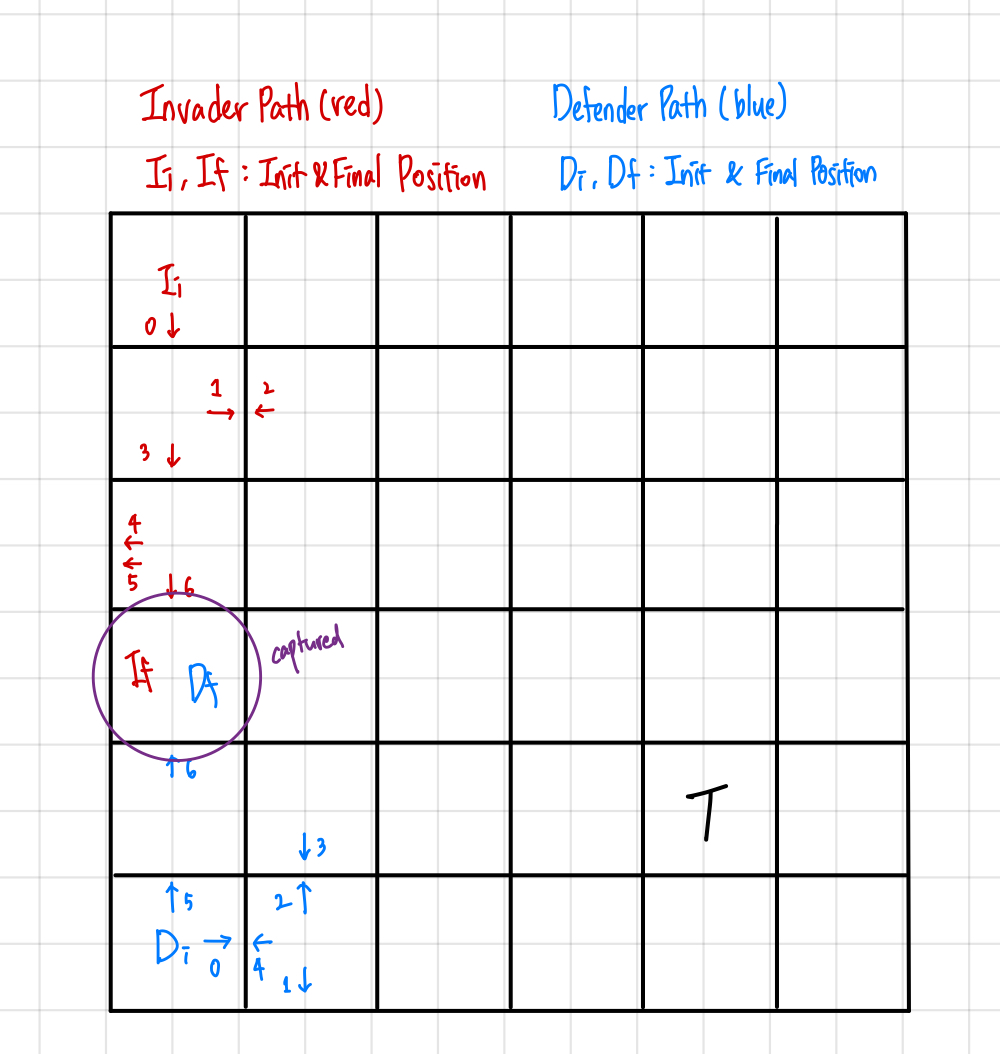

In [32]:
from IPython.display import Image, display
display(Image(filename='fig2.3.4.jpeg', width=400))

### 3. Results discussion [30 Marks]

In your report, please provide details about the results of your experiment. Include all relevant plots to support
your answers:

**NOTE**: All of the questions being answered below make use of identical hyperparameters across the algorithms (Learning rate = 5e-5, and Epsilon = 0.1) to allow for direct comparison. We initially experimented with Distributed Q-learning to find this as the best combination, and decided to use it for the remaining 2 algorithims to maintain consistency across algorithms.

3.1. Did your algorithms converge? How many iterations did they take?     [5 Marks]

With the hyperparameters specified above, all of the algorithms were able to converge, as shown throughout all of the hyperparameter exploration in sections 2.1-2.3.

For Distributed Q-learning, on average we found convergence after ~50k episodes when there was a high learning rate e.g 0.7, but lower learning rates like 5e-5 were much more reasonable with ~40 or less episodes until convergence.

For Shapley Value Iteration, on average we found convergence after 9 episodes, regardless of the hyperparameters we tested.

For MiniMax Q-learning, on average it was difficult to determine when it converged as the result was different each time the algorithm was run. Some instances it converged fast within 10-20 episodes, and in some instances it took >50 episodes for the same set of hyperparameters, but generally lower learning rates like 1e-5 did better. 

3.2. What were the final policies? Do the final policies agree between value iteration and Q-learning? What do
you think could explain the differences between them, if any? [5 Marks]

Episode 1.
	Game terminated
	Invader Captured
	Terminating State: ((4, 1), (5, 1))
	Number of Steps: 44
	Invader Reward: 5; Defender Reward: -5
Episode 2.
	Game terminated
	Territory Captured
	Terminating State: ((4, 4), (4, 1))
	Number of Steps: 57
	Invader Reward: 111; Defender Reward: -111
Episode 3.
	Game terminated
	Invader Captured
	Terminating State: ((0, 3), (1, 2))
	Number of Steps: 14
	Invader Reward: -11; Defender Reward: 11
Episode 4.
	Game terminated
	Invader Captured
	Terminating State: ((2, 3), (3, 3))
	Number of Steps: 11
	Invader Reward: -1; Defender Reward: 1
Episode 5.
	Game terminated
	Territory Captured
	Terminating State: ((4, 4), (3, 1))
	Number of Steps: 43
	Invader Reward: 93; Defender Reward: -93
Episode 6.
	Exceeded 200 steps
	Invader Reward: -600; Defender Reward: 600
Episode 7.
	Game terminated
	Territory Captured
	Terminating State: ((4, 4), (3, 0))
	Number of Steps: 20
	Invader Reward: 52; Defender Reward: -52
Episode 8.
	Exceeded 200 steps
	Invader Rewar

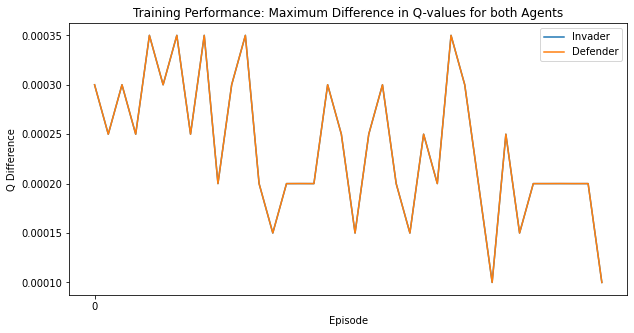

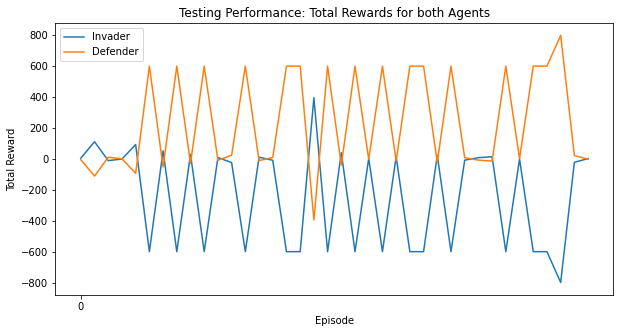

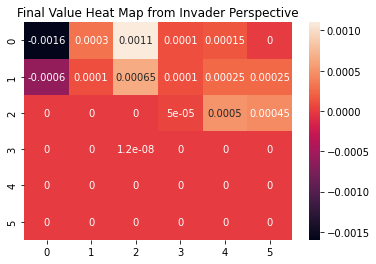

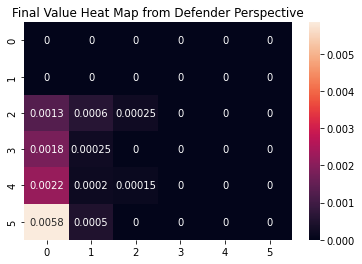

In [35]:
# Print policies for Distributed Q-learning
env = InvaderDefenderEnv()
distributed_q_learning = DistributedQLearning(env, lr=5e-5, epsilon=0.1, convergence_threshold=1e-4)
Q_inv, Q_def, DistQ_policy_inv, DistQ_policy_def = distributed_q_learning.train()

In [37]:
print(f"Distributed Q-learning Invader Policy: {DistQ_policy_inv}")
print()
print(f"Distributed Q-learning Defender Policy: {DistQ_policy_def}")

Distributed Q-learning Invader Policy: {((0, 0), (0, 0)): {'l': 0.25, 'r': 0.25, 'u': 0.25, 'd': 0.25}, ((0, 0), (0, 1)): {'l': 0.25, 'r': 0.25, 'u': 0.25, 'd': 0.25}, ((0, 0), (0, 2)): {'l': 0.25, 'r': 0.25, 'u': 0.25, 'd': 0.25}, ((0, 0), (0, 3)): {'l': 0.25, 'r': 0.25, 'u': 0.25, 'd': 0.25}, ((0, 0), (0, 4)): {'l': 0.25, 'r': 0.25, 'u': 0.25, 'd': 0.25}, ((0, 0), (0, 5)): {'l': 0.25, 'r': 0.25, 'u': 0.25, 'd': 0.25}, ((0, 0), (1, 0)): {'l': 0.25, 'r': 0.25, 'u': 0.25, 'd': 0.25}, ((0, 0), (1, 1)): {'l': 0.25, 'r': 0.25, 'u': 0.25, 'd': 0.25}, ((0, 0), (1, 2)): {'l': 0.25, 'r': 0.25, 'u': 0.25, 'd': 0.25}, ((0, 0), (1, 3)): {'l': 0.25, 'r': 0.25, 'u': 0.25, 'd': 0.25}, ((0, 0), (1, 4)): {'l': 0.25, 'r': 0.25, 'u': 0.25, 'd': 0.25}, ((0, 0), (1, 5)): {'l': 0.25, 'r': 0.25, 'u': 0.25, 'd': 0.25}, ((0, 0), (2, 0)): {'l': 0.3333333333333333, 'r': 0.0, 'u': 0.3333333333333333, 'd': 0.3333333333333333}, ((0, 0), (2, 1)): {'l': 0.0, 'r': 0.5, 'u': 0.5, 'd': 0.0}, ((0, 0), (2, 2)): {'l': 0.0

Episode 1.
	Exceeded 200 steps
	Invader Reward: 791; Defender Reward: -791
Episode 2.
	Exceeded 200 steps
	Invader Reward: 875; Defender Reward: -875
Episode 3.
	Game terminated
	Invader Captured
	Terminating State: ((3, 4), (3, 3))
	Number of Steps: 8
	Invader Reward: -4; Defender Reward: 4
Episode 4.
	Game terminated
	Invader Captured
	Terminating State: ((2, 4), (2, 3))
	Number of Steps: 7
	Invader Reward: -5; Defender Reward: 5
Episode 5.
	Game terminated
	Invader Captured
	Terminating State: ((2, 4), (2, 3))
	Number of Steps: 7
	Invader Reward: -5; Defender Reward: 5
Episode 6.
	Game terminated
	Invader Captured
	Terminating State: ((2, 4), (3, 4))
	Number of Steps: 7
	Invader Reward: -5; Defender Reward: 5
Episode 7.
	Game terminated
	Invader Captured
	Terminating State: ((2, 4), (3, 4))
	Number of Steps: 7
	Invader Reward: -5; Defender Reward: 5
Episode 8.
	Game terminated
	Invader Captured
	Terminating State: ((2, 4), (3, 4))
	Number of Steps: 7
	Invader Reward: -5; Defender Re

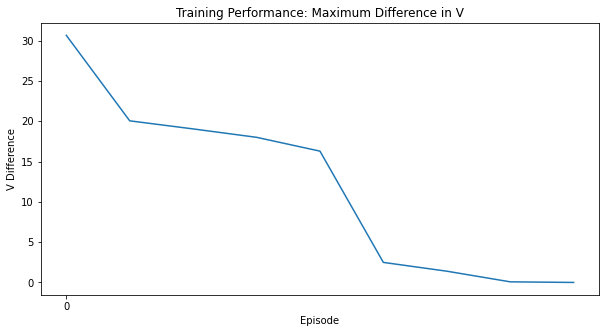

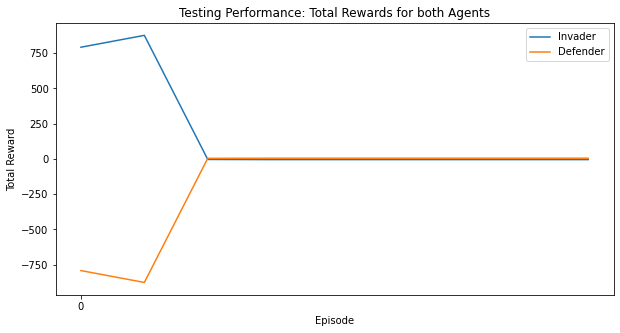

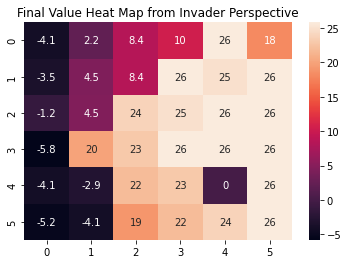

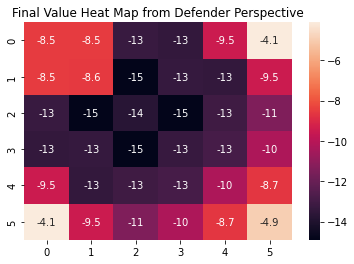

In [38]:
env = InvaderDefenderEnv()
shapley_value_iteration = ShapleyValueIteration(env, lr=5e-5, epsilon=0.1, convergence_threshold=1e-4)
U, Shapley_policy_inv, Shapley_policy_def = shapley_value_iteration.train()

In [39]:
print(f"Shapley Value Iteration Invader Policy: {Shapley_policy_inv}")
print()
print(f"Shapley Value Iteration Defender Policy: {Shapley_policy_def}")

Shapley Value Iteration Invader Policy: {((0, 0), (0, 0)): {'l': 0.0, 'r': 0.5058049026512417, 'u': 0.0, 'd': 0.4941950973487583}, ((0, 0), (0, 1)): {'l': 0.0, 'r': 0.5881677398137285, 'u': 0.0, 'd': 0.4118322601862715}, ((0, 0), (0, 2)): {'l': 0.0, 'r': 0.6366187514405865, 'u': 0.0, 'd': 0.36338124855941345}, ((0, 0), (0, 3)): {'l': 0.0, 'r': 0.0, 'u': 0.0, 'd': 1.0}, ((0, 0), (0, 4)): {'l': 0.0, 'r': 0.0, 'u': 0.0, 'd': 1.0}, ((0, 0), (0, 5)): {'l': 0.0, 'r': 0.0, 'u': 0.0, 'd': 1.0}, ((0, 0), (1, 0)): {'l': 0.0, 'r': 0.41183226018627156, 'u': 0.0, 'd': 0.5881677398137284}, ((0, 0), (1, 1)): {'l': 0.0, 'r': 0.5, 'u': 0.0, 'd': 0.5}, ((0, 0), (1, 2)): {'l': 0.0, 'r': 1.0, 'u': 0.0, 'd': 0.0}, ((0, 0), (1, 3)): {'l': 0.0, 'r': 0.6149755400455419, 'u': 0.0, 'd': 0.3850244599544581}, ((0, 0), (1, 4)): {'l': 0.0, 'r': 0.0, 'u': 0.0, 'd': 1.0}, ((0, 0), (1, 5)): {'l': 0.0, 'r': 0.0, 'u': 0.0, 'd': 1.0}, ((0, 0), (2, 0)): {'l': 0.0, 'r': 0.3633812485594137, 'u': 0.0, 'd': 0.6366187514405863

Episode 1.
	Exceeded 200 steps
	Invader Reward: -798; Defender Reward: 798
Episode 2.
	Game terminated
	Invader Captured
	Terminating State: ((1, 0), (1, 0))
	Number of Steps: 7
	Invader Reward: -35; Defender Reward: 35
Episode 3.
	Exceeded 200 steps
	Invader Reward: -305; Defender Reward: 305
Episode 4.
	Game terminated
	Invader Captured
	Terminating State: ((3, 0), (4, 1))
	Number of Steps: 18
	Invader Reward: -63; Defender Reward: 63
Episode 5.
	Exceeded 200 steps
	Invader Reward: -502; Defender Reward: 502
Episode 6.
	Game terminated
	Invader Captured
	Terminating State: ((2, 0), (3, 0))
	Number of Steps: 8
	Invader Reward: -29; Defender Reward: 29
Episode 7.
	Exceeded 200 steps
	Invader Reward: -501; Defender Reward: 501
Episode 8.
	Exceeded 200 steps
	Invader Reward: -108; Defender Reward: 108
Episode 9.
	Exceeded 200 steps
	Invader Reward: -301; Defender Reward: 301
Episode 10.
	Game terminated
	Invader Captured
	Terminating State: ((2, 0), (3, 0))
	Number of Steps: 8
	Invader R

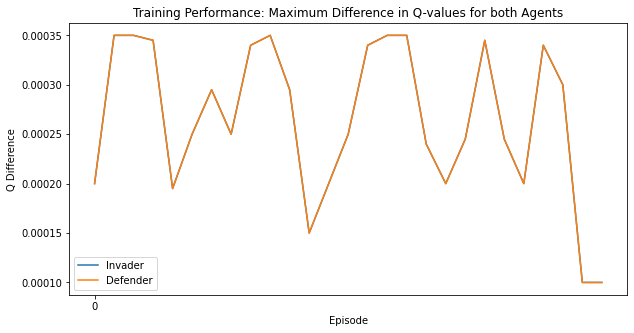

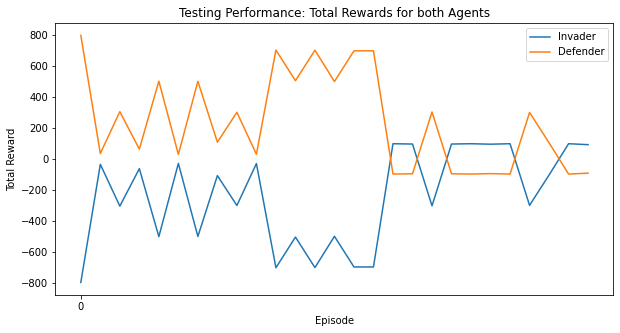

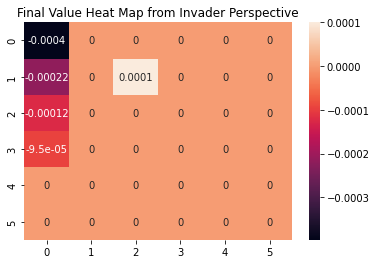

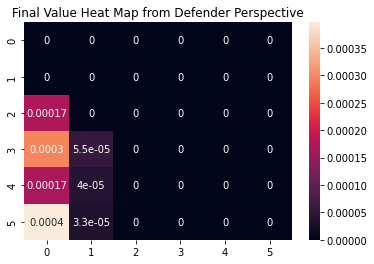

In [40]:
env = InvaderDefenderEnv()
minimax_q_learning = MinimaxQLearning(env, lr=5e-5, epsilon=0.1, convergence_threshold=1e-4)
Q_inv, Q_def, MinimaxQ_policy_inv, MinimaxQ_policy_def = minimax_q_learning.train()

In [44]:
print(f"MiniMax Q-learning Invader Policy: {MinimaxQ_policy_inv}")
print()
print(f"MiniMax Q-learning Defender Policy: {MinimaxQ_policy_def}")

MiniMax Q-learning Invader Policy: {((0, 0), (0, 0)): {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}, ((0, 0), (0, 1)): {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}, ((0, 0), (0, 2)): {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}, ((0, 0), (0, 3)): {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}, ((0, 0), (0, 4)): {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}, ((0, 0), (0, 5)): {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}, ((0, 0), (1, 0)): {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}, ((0, 0), (1, 1)): {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}, ((0, 0), (1, 2)): {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}, ((0, 0), (1, 3)): {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}, ((0, 0), (1, 4)): {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}, ((0, 0), (1, 5)): {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}, ((0, 0), (2, 0)): {'l': 0.2892546039409167, 'r': 0.23140946834123016, 'u': 0.23140341005421022, 'd': 0.24793251766364288}, ((0, 0), (2, 1)): {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}, ((0, 0), (2, 2)): {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}, (

The final three policies (for the hyperparameters specified) have been printed above.

We can immediately see that the final policies differ between the three algorithms. Some examples are provided below:

**NOTE**: These values are from one training instance, and may change if run again.

- Distributed Q-learning:
    - Invader policy at state ((0,0), (0,0)) : {'l': 0.25, 'r': 0.25, 'u': 0.25, 'd': 0.25}, Defender policy at state ((0,0), (0,0)) : {'l': 0.25, 'r': 0.25, 'u': 0.25, 'd': 0.25}
    - Invader policy at state ((0, 0), (1, 3)): {'l': 0.25, 'r': 0.25, 'u': 0.25, 'd': 0.25}, Defender policy at state ((0, 0), (1, 3)): {'l': 0.25, 'r': 0.25, 'u': 0.25, 'd': 0.25}

- Shapley Value Iteration:
    - Invader policy at state ((0,0), (0,0)) : {'l': 0.0, 'r': 0.5058049026512417, 'u': 0.0, 'd': 0.4941950973487583}, Defender policy at state ((0,0), (0,0)) :  {'l': 0.0, 'r': 0.46238543553448447, 'u': 0.07522912893103105, 'd': 0.4623854355344844}
    - Invader policy at state ((0, 0), (1, 3)): {'l': 0.0, 'r': 0.6149755400455419, 'u': 0.0, 'd': 0.3850244599544581}, Defender policy at state ((0, 0), (1, 3)): {'l': -0.0, 'r': 0.0, 'u': 0.0, 'd': 1.0}

- MiniMax Q-learning:
    - Invader policy at state ((0,0), (0,0)) : {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}, Defender policy at state ((0,0), (0,0)) : {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}
    - Invader policy at state ((0, 0), (1, 3)): {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}, Defender policy at state ((0, 0), (1, 3)): {'l': 1.0, 'r': 0.0, 'u': 0.0, 'd': 0.0}

Some general points to summarize our findings:

- Distributed Q-learning:
    - Has with uniform exploration (0.25 probability for all actions) in most states.

- Shapley Value Iteration:
    - Uses probabilistic strategies that often balance multiple actions, e.g., favoring right (r) and down (d) movements in early positions like ((0,0), (0,0)) with probabilities 0.506/0.494 for the Invader.
    - Shows adaptive tradeoffs between exploration and exploitation, with some states becoming deterministic (e.g., ((0,0), (1,3)): d: 1.0) for Defender.
    
- MiniMax Q-learning:
    - Employs deterministic actions in most states.
    - Prioritizes risk minimization by selecting the safest available action, particularly near walls (e.g., ((0,0), (2,1)): u: 1.0 or l: 1.0) for the Invader (trying its best to avoid Defender).


3.3 Looking at the final policy you obtained, were there any states in which the optimal mini-max equilibrium was
non-deterministic (that is, either defender or invader or both agents take action randomly)? Please include a
list of all such states in your report. Do you think this result is expected? Why or why not?. [5 Marks]

In [47]:
Shapley_non_deterministic_keys_inv = {
    key for key, value in Shapley_policy_inv.items()
    if 1.0 not in value.values()
}
Shapley_non_deterministic_keys_def = {
    key for key, value in Shapley_policy_def.items()
    if 1.0 not in value.values()
}
print(f"Non-deterministic states for Invader (Shapley Value Iteration): {Shapley_non_deterministic_keys_inv}\nTotal number = {len(Shapley_non_deterministic_keys_inv)}/1296 states")
print(f"Non-deterministic states for Defender (Shapley Value Iteration): {Shapley_non_deterministic_keys_def}\nTotal number = {len(Shapley_non_deterministic_keys_def)}/1296 states")

Non-deterministic states for Invader (Shapley Value Iteration): {((2, 1), (1, 0)), ((2, 0), (2, 0)), ((5, 3), (4, 4)), ((0, 0), (4, 4)), ((1, 4), (4, 5)), ((1, 0), (3, 2)), ((1, 0), (4, 3)), ((1, 0), (2, 0)), ((1, 2), (1, 0)), ((5, 0), (5, 2)), ((2, 0), (5, 1)), ((2, 1), (2, 3)), ((5, 2), (5, 2)), ((2, 1), (0, 1)), ((3, 5), (2, 4)), ((3, 3), (2, 2)), ((1, 0), (4, 5)), ((1, 2), (1, 2)), ((1, 2), (2, 3)), ((3, 0), (3, 2)), ((0, 3), (1, 4)), ((1, 2), (0, 1)), ((5, 1), (5, 3)), ((5, 5), (4, 4)), ((1, 0), (1, 0)), ((0, 3), (0, 3)), ((5, 0), (4, 3)), ((0, 1), (3, 4)), ((3, 1), (3, 1)), ((5, 2), (4, 3)), ((0, 1), (0, 0)), ((2, 0), (3, 0)), ((3, 2), (3, 4)), ((5, 0), (5, 1)), ((1, 0), (1, 2)), ((5, 3), (5, 4)), ((1, 0), (2, 3)), ((1, 0), (0, 1)), ((1, 0), (3, 0)), ((0, 0), (2, 0)), ((3, 3), (4, 4)), ((0, 2), (2, 0)), ((2, 1), (2, 1)), ((2, 5), (4, 5)), ((0, 3), (5, 3)), ((3, 0), (3, 0)), ((2, 0), (0, 2)), ((0, 1), (1, 4)), ((5, 5), (5, 4)), ((0, 0), (1, 0)), ((0, 1), (0, 3)), ((3, 5), (5, 3)),

In [49]:
MiniMaxQ_non_deterministic_keys_inv = {
    key for key, value in MinimaxQ_policy_inv.items()
    if 1.0 not in value.values()
}
MiniMaxQ_non_deterministic_keys_def = {
    key for key, value in MinimaxQ_policy_def.items()
    if 1.0 not in value.values()
}
print(f"Non-deterministic states for Invader (MiniMax Q-learning): {MiniMaxQ_non_deterministic_keys_inv}\nTotal number = {len(MiniMaxQ_non_deterministic_keys_inv)}/1296 states")
print(f"Non-deterministic states for Defender (MiniMax Q-learning): {MiniMaxQ_non_deterministic_keys_def}\nTotal number = {len(MiniMaxQ_non_deterministic_keys_def)}/1296 states")

Non-deterministic states for Invader (MiniMax Q-learning): {((1, 1), (5, 1)), ((0, 2), (4, 2)), ((0, 1), (3, 1)), ((1, 0), (3, 0)), ((2, 1), (4, 0)), ((0, 0), (2, 0)), ((3, 1), (5, 1)), ((0, 0), (5, 0)), ((2, 1), (4, 1)), ((0, 5), (4, 4)), ((2, 0), (5, 0)), ((1, 0), (2, 0)), ((0, 0), (5, 1)), ((0, 4), (5, 3)), ((0, 0), (4, 0)), ((2, 0), (5, 1)), ((1, 0), (5, 0)), ((2, 0), (4, 0)), ((0, 1), (5, 1)), ((1, 0), (5, 1)), ((0, 0), (4, 1)), ((1, 5), (3, 5)), ((1, 0), (4, 0)), ((0, 1), (2, 1)), ((0, 1), (4, 1)), ((3, 0), (5, 0)), ((1, 0), (4, 1)), ((0, 0), (3, 0)), ((0, 0), (3, 1)), ((0, 5), (2, 5)), ((2, 1), (5, 1))}
Total number = 31/1296 states
Non-deterministic states for Defender (MiniMax Q-learning): {((1, 1), (5, 1)), ((0, 2), (4, 2)), ((0, 1), (3, 1)), ((1, 0), (3, 0)), ((2, 1), (4, 0)), ((0, 0), (2, 0)), ((3, 1), (5, 1)), ((0, 0), (5, 0)), ((2, 1), (4, 1)), ((0, 5), (4, 4)), ((2, 0), (5, 0)), ((1, 0), (2, 0)), ((0, 0), (5, 1)), ((0, 0), (4, 0)), ((2, 0), (5, 1)), ((1, 0), (5, 0)), ((2

We would say that these results above are as expected.

**NOTE**: the values provided below are again for one instance. Values may change if the codeblocks above are re-run.

1. Shapley Value Iteration:
- Non-deterministic states:
    - Invader: 152/1296 states (~11.7%).
    - Defender: 278/1296 states (~21.5%).

Expected? Yes, but with caveats.

The Shapley value is a cooperative game theory concept designed to fairly distribute rewards in collaborative settings. However, this problem is competitive (defender vs. invader). When repurposing Shapley values for adversarial settings, ambiguity arises in assigning "credit" or "blame." In states where agents’ contributions to outcomes are symmetric or ambiguous (e.g., both agents have equally good/bad options), the Shapley value will not resolve to a single deterministic action. The large number of non-deterministic states reflects the algorithm’s struggle to resolve competition into clear policies.

The high percentage (21.5% for the defender) might seem excessive. In purely adversarial settings, deterministic policies are often preferred (e.g., Minimax), so this suggests the Shapley approach may not fully align with the problem’s competitive nature.

2. Minimax Q-learning:
- Non-deterministic states:
    - Invader: 41/1296 states (~3.2%).
    - Defender: 40/1296 states (~3.1%).

Expected? Yes.

Minimax Q-learning is designed for zero-sum games, where agents optimize against worst-case opponents. In such games, mixed strategies (probabilistic actions) are often required at equilibrium to avoid being exploited. In other words, mixed strategies are needed only in specific scenarios. For example, if the defender cannot deterministically block all invader paths (due to simultaneous moves or capture probability), randomization becomes necessary. The low percentage (~3%) suggests most states have a clear deterministic minimax equilibrium, but a small subset requires mixed strategies. Given the grid’s complexity and stochastic capture mechanics (90% chance), some non-determinism is natural.

3.4 Based on your heat-map plots, for which initial states does the invader win and defender lose (e.g. the invader
makes it to the territory and evades capture)? Similarly, for which initial states does the defender win and
invader lose (e.g. the invader is captured before reaching the territory)? Are there any starting states in which
it is not clear whether invader and defender will win the game? Explain. [10 Marks]

1. Distributed Q-learning

We will analyze the heat maps below, which resulted from a training instance with the hyperparameters specified earlier:

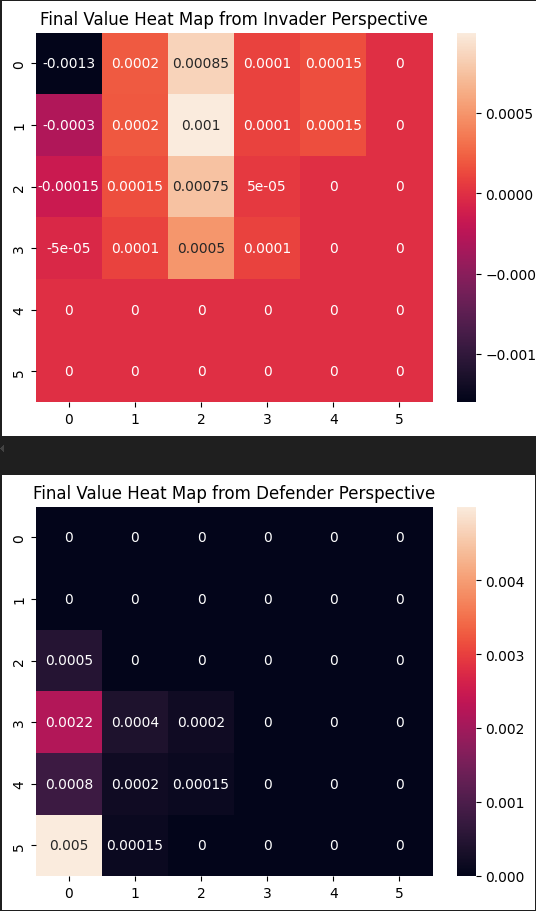

**Invader's Perspective**:
- Negative vs. Positive Values:
    - Several cells in the leftmost column (for example, row 0 at -0.0013, row 1 at -0.0003, row 2 at -0.00015, and row 3 at -5e-5) show negative values. These indicate that when the invader starts in those positions (i.e. at or very near the left edge), its outcome is predicted to be worse—likely because it is closer to the defender’s fixed position at the bottom-left, increasing the risk of early capture.
    - In contrast, more central cells—especially along row 0–1 at column 2 (0.00085 and 0.001, respectively)—exhibit higher positive values. These indicate that, from the invader’s standpoint, starting toward the middle (and to the right of the left edge) makes reaching the territory T more likely and reduces the risk of capture.

- Zero Values:
    - The complete rows 4 and 5 (and some cells in other rows) with a value of 0 likely signal that the invader never encountered a clear advantage or disadvantage when starting there during training. It can be interpreted as these positions being ambiguous for the invader—perhaps they were rarely visited or the learned rewards nearly canceled out.

**Interpretation:**
- Winning States for the Invader: When the invader starts in cells that yield a positive Q-value (for example, row 1, column 2 is the highest at 0.001), the learned policy predicts a better chance to eventually reach the territory T before being captured.

- Losing States for the Invader: Negative Q-values (as seen in the leftmost column) indicate that those starting positions lead to outcomes where the invader is more likely to be captured by the defender.

- Ambiguous States: Cells showing exactly zero suggest that the algorithm did not learn a clear preference—small variations or stochastic behavior might then decide the actual outcome in these states.

**Defender's Perspective**:
- Higher Positive Defender Values:
    - The highest value observed is 0.005 at row 5, column 0. This is the bottom-left corner—the same cell at which the defender was fixed in the invader experiment. It indicates that starting in this position is highly favorable for the defender when facing an invader fixed at the top left (cell (0,0)).
    - Other nonzero values are present in rows 2–4 with progressively smaller magnitudes. This suggests that while there is some advantage in those positions, the defender’s best chance to capture the invader (or to maximize its reward) is when starting at the bottom left.

- Zero Values:
    - Rows 0 and 1 are entirely zeros. This implies that when the defender starts in the top of the grid (closer to the invader’s fixed location in this experiment), it does not gain a clear advantage in terms of the expected reward under the learned policy. This might be due to immediate capture not being as favorable (or because the algorithm did not experience these states as often during training).

**Interpretation**:
- Winning States for the Defender: The defender learns that starting in the bottom left (or cells nearby, such as row 3 or row 5, column 0) yields a significantly better (positive) value. This position likely maximizes the opportunity to capture the invader coming from the top left.
- Losing or Ambiguous States for the Defender: Zeros in the upper rows indicate that starting there does not provide a marked advantage. In these states, the policy may be less decisive regarding capture, so the outcome might be ambiguous or less favorable.

-----------------------------------

2. Shapley Value Iteration:

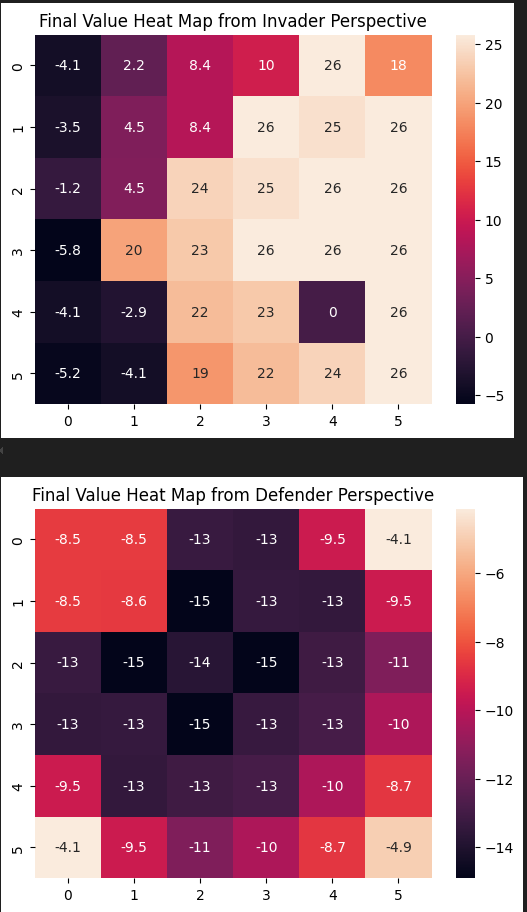

**Invader's Perspective:**
- High-Value Regions (e.g., values 26, 25, 26, etc.):
    - In many cells, particularly from columns 3–5 in rows 0–4 and rows 6, the learned values are very high (often at 26 and 25).
    - Interpretation: These cells clearly indicate starting positions from which the invader’s policy expects a very favorable outcome. In other words, if the invader starts in these locations, it is likely to successfully reach territory T, likely because these positions are farther from the defender’s immediate influence (fixed in the bottom left) and closer to the territory target.

- Moderate Positive Values in Central Regions: 
    - Some cells in the mid-range (e.g., 8.4 or 10 in the upper rows, 22 or 23 in row 5) suggest intermediate outcomes.
    - Interpretation: Starting in these locations is beneficial but not as decisively positive as those with values at 26. This likely reflects trade-offs between advancing toward the goal and the risk of capture.

- Negative Values in the Leftmost Column:
    - The leftmost column contains negative values (e.g., -4.1, -3.5, -1.2, -1.2, -5.8, -4.1, -5.2).
    - Interpretation: These indicate that if the invader begins near the left edge of the grid—closer to the defender’s fixed location—the outcome is poor. Negative learned values show that the invader is more likely to be captured or that progress toward T is significantly hindered.

**Defender's Perspective:**
- Uniformly Negative Values:
    - All cells are negative, which is expected in a zero-sum.
    - Interpretation: In these terms, higher (or less negative) numbers represent relatively better outcomes for the defender because they imply a smaller “loss” (or disadvantage). Conversely, the more negative values correlate with states where the defender is at a larger disadvantage.

- Better Defender Values:
    - The least negative values occur in Row 0 (e.g., -4.1 in the rightmost cell) and Row 5 (e.g., -4.1 at the leftmost cell and -4.9 in the rightmost column). 
    - Interpretation: When the defender’s values are only mildly negative, it indicates that if the invader is starting from these corresponding states (from the invader’s perspective, those are the high-value winning states), the defender has a relatively better outcome.
    - However, even these “better” values are still negative, reflecting that in Shapley Value Iteration the defender is typically at a disadvantage when the invader’s optimal moves are enabled.

- Worse Defender Values in Central Regions:
    - The central regions, where the invader's values are highest (26’s and 25’s), coincide with more negative outcomes for the defender (values ranging from -13 to -15).
    - Interpretation: This suggests that if the invader starts in those central/right positions where the invader’s policy is strong, the defender is expected to lose control, reinforcing that those starting states are unfavorable for the defender.

**Combined Interpretation**:

Invader-Favorable (Invader Wins and Defender Loses)

- Invader’s Evidence: Cells with high values (26, 25, 26) in the invader’s heatmap – primarily toward the right half and some central locations – clearly indicate that from these positions the invader is likely to succeed in reaching the target territory.
- Defender’s Evidence: In these same regions, the defender’s heatmap shows strongly negative values (often between -13 and -15), which signifies that these starting states are particularly harmful for the defender.

Defender-Favorable (Defender Wins and Invader Loses)

- Invader’s Evidence: Starting positions in the leftmost column, where the invader values are negative (e.g., -4.1 to -5.2), imply that the invader is at a disadvantage and likely to be captured.

- Defender’s Evidence: The defender’s corresponding values in these areas are “less negative” (e.g., around -8.5 to -9.5 in the upper rows, or -4.1 in row 5), suggesting that the defender is in a comparatively better position to capture the invader when the invader starts from these spots.

Ambiguous or Borderline States

- Invader’s Heatmap: Intermediate values (e.g., around 8.4, 10, 22, or 23) indicate borderline states where the benefit of being closer to the territory may be partially offset by the risk of defender capture. The one cell with a 0 value in row 5 further points to ambiguity.

- Defender’s Heatmap: While the values are uniformly negative, the range provides a spectrum of outcomes. Where these negatives are less severe, the defender might have a chance of winning; where they are very low (i.e., very negative), the defender is at a considerable disadvantage.

- Interpretation: In these ambiguous cells, minor environmental variations or early decisions could flip the expected outcome from one side to the other.

-----------------------------------

3. MiniMax Q-learning:

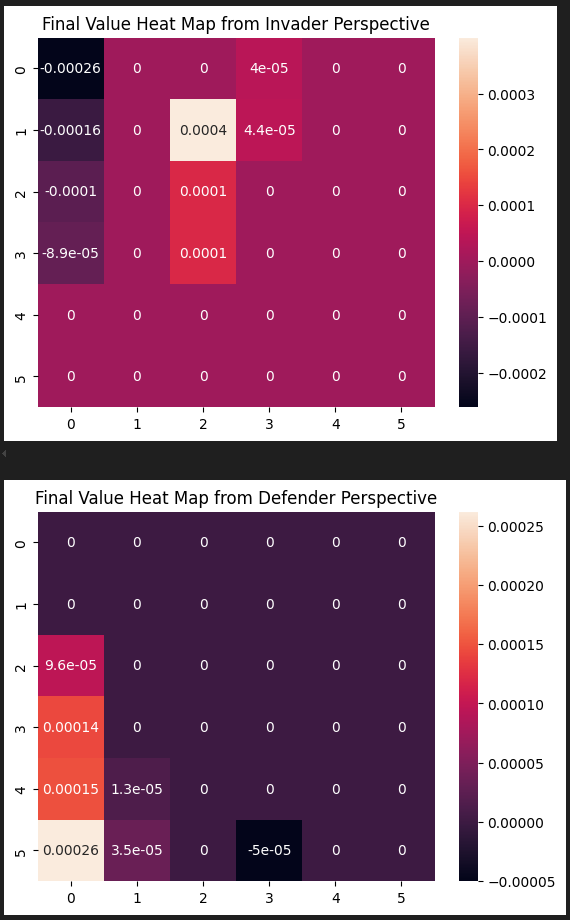

**Invader's Perspective:**
- Negative Values Along the Leftmost Column:
    - The invader’s states at positions such as (0,0), (1,0), (2,0), and (3,0) are negative (e.g., -0.00026, -0.00016, etc.).
    - Interpretation: These negative values imply that if the invader starts in these left-edge cells, its chance of reaching the territory T is lower (likely because these positions are too close to the defender’s ideal capture zone).

- Positive Values in Central Cells:
    - In row 2, column 2 there is a positive value of 0.001—the highest among all recorded values.
    - Also, small positive values exist in row 0, col3 (4e-5) and row 1, col3 (4.4e-5) as well as row 1, col2 (0.0004).
    - Interpretation: These indicate that starting somewhere in the center (or slightly to the right from the left edge) gives the invader a marginally better outcome, suggesting that these positions better balance the trade-off between advancing toward the territory T and avoiding a severe worst-case defender response.

- Cells with Zero:
    - The entire rows 4 and 5 have learned values of 0.
    - Interpretation: A value of zero typically reflects ambiguous outcomes—a state that either was rarely encountered during training or one where the opposing effects (advancing toward T versus the risk of capture) cancel out. The algorithm does not find a clear advantage for the invader in these starting positions.

**Defender's Perspective:**
- Positive Defender Values in Mid-to-Upper Lower Rows:
    - The defender sees positive values in rows 2–4, particularly in the leftmost column: for example, row 2, col0 (9.6e-5), row 3, col0 (0.00014), and row 4, col0 (0.00015).
    - Interpretation: These positions are predicted to be advantageous for the defender. In these states, if the defender starts in the left region of the grid (but not necessarily in the extreme bottom row), it can better anticipate and counter the invader’s moves when the invader is fixed at (0,0).

- Mixed Signals in the Bottom Row (Row 5):
    - In row 5, we see a negative value at (5,0) of -0.00026 and a modest positive value at (5,1) (3.5e-5), with another negative at (5,3) (-5e-5).
    - Interpretation: The negative values in row 5 indicate that starting in some extreme bottom positions might be less advantageous under the minimax criterion. It suggests that—even though the defender might traditionally benefit from starting near its “home” location—the minimax formulation penalizes some extreme cases if the worst-case response from the invader becomes particularly detrimental.

- Cells with Zero:
    - The top two rows (rows 0 and 1) are entirely zero.
    - Interpretation: These values mean that if the defender starts near the invader (the top of the grid), it does not enjoy any clear advantage. The value is neutral, reflecting that the defender’s chance to force a capture is either very similar to the baseline or that these states weren’t significantly reinforced during training.

**Combined Interpretation:**

Invader-Favorable Starting States (Invader wins, Defender loses):

- From the Invader’s Perspective:
    - Central Positions: Cells like (2,2) where the value is 0.001 are the most favorable.
    - Interpretation: Starting in these central locations reduces the immediate risk from the defender’s worst-case responses and provides a relatively better chance of reaching territory T before being captured.

- From the Defender’s Perspective:
    - Disadvantageous States: In corresponding regions (for example, positions in the bottom row are mixed or even negative) the learned values indicate that if the invader happens to start from these central positions, the defender’s counter-strategy is less effective.

Defender-Favorable Starting States (Defender wins, Invader loses):

- From the Defender’s Perspective:
    - Positions in Row 2–4, Column 0: Positive values (9.6e-5 to 0.00015) imply that when the defender starts in these leftmost cells—not extremely bottom (since row 5 shows negatives)—its strategy is stronger and more effective in countering the invader (fixed at top left).
    - Interpretation: These positions likely allow the defender to capture early or better position to react against the invader.

- From the Invader’s Perspective:
    - Leftmost Column: The consistently negative values (e.g., -0.00026 at (0,0), -0.00016 at (1,0)) suggest that the invader is at a disadvantage if it begins close to where the defender can optimally operate.

Ambiguous or Borderline States:

- Zero-Valued Cells:
    - Many cells (such as the entire rows 4–5 for the invader and rows 0–1 for the defender) record a zero value.
    - Interpretation: These ambiguous states suggest that neither outcome (win or loss) is clearly predicted. Minor variations in the environment or small stochastic differences during play could push the result in either direction. In these areas, the minimax algorithm did not reinforce a strong preference for one outcome over the other.

3.5. Which algorithm did you feel was more reliable for solving this task? Which algorithm would be more efficient
if the state space was considerably larger?.[5 Marks]

Theoretically speaking, Minimax Q-learning is the best choice for this competitive task. It explicitly accounts for the opponent’s optimal counter-strategy. The invader maximizes its reward (primal LP) while assuming the defender minimizes it (via the minimax equilibrium). It's also particularly good at handling simultaneous actions and stochastic outcomes (e.g., 90% capture chance) by optimizing for worst-case scenarios.

In terms of what we saw when running these algorithms ourselves, Shapley Value Iteration converged faster and more stably. It was able to converge even with the tightest threshold (1e−6) consistently within 200 episodes due to its policy iteration nature (no exploration vs. exploitation trade-off). The one downside we noticed was its high non-determinism (~21% for defender) which led to suboptimal policies. Minimax Q-learning and Distributed Q-learning both struggles with convergence; they both failed to meet the stricter threshold (1e−6) with learning rates >5e−5, even after 200 episodes. Minimax Q-learning did however appear to produce the most task-effective policies despite these convergence challenges; non-deterministic states were rather minimal (~3%) and were concentrated near critical chokeholds (e.g., near T or defender’s capture zone), where randomization prevents predictability.

In terms of which algorithm would be more efficient if the state space was much larger, we believe **Distributed Q-learning** would perform the best.

Distributed Q-learning avoids centralized computation. Each agent learns independently with its own Q-table, reducing memory and computational overhead. For example, in a grid with N cells, each agent’s Q-table scales with O(N * actions), whereas Minimax and Shapley scale much poorly. Also, Distributed Q-learning can be parallelized across agents, unlike Shapley or Minimax, which require centralized coordination. Thus, intuitively, Distributed Q-learning would achieve best computational efficiency.

